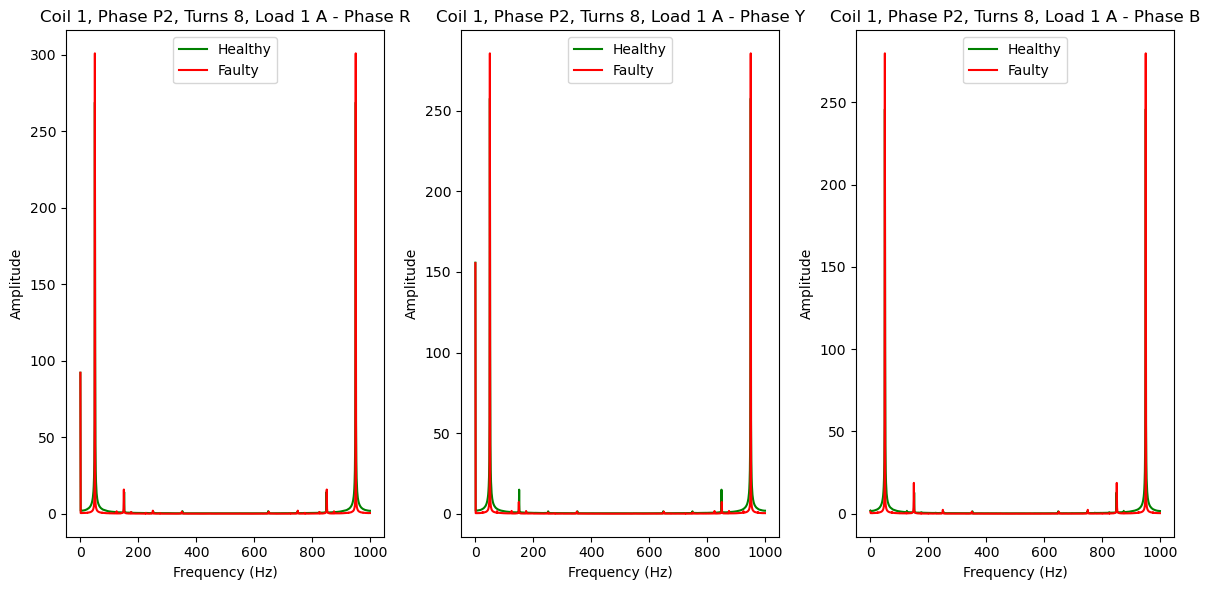

In [1]:
#THIS CODE IS ONLY FOR Y PHASE FAULTS MANUALLY CHANGE EACH BLOCK OF CODE TO NECESSARY PHASE TO FIND FAULT OF THAT PHASE
#VISUALIZING VARIOUS R,Y,B FAULTS USNG FFT PLOTTING
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft

def load_and_process_file(file_path, segment_length=1000):
    """
    Load a file, split it into segments, and compute the FFT for each segment.
    """
    try:
        # Load the CSV file
        df = pd.read_csv(file_path, header=None)
        current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

        # Split into 1-second segments (1000 samples per segment)
        segments = [current_data[i:i + segment_length] for i in range(0, len(current_data), segment_length) if i + segment_length <= len(current_data)]

        # Compute FFT for each segment and average the results
        fft_results = []
        for segment in segments:
            fft_result = np.abs(fft(segment, axis=0))  # Compute FFT for each phase
            fft_results.append(fft_result)
        avg_fft = np.mean(fft_results, axis=0)  # Average FFT across segments

        return avg_fft

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return None

def plot_fft_comparison(healthy_fft, faulty_fft, title):
    """
    Plot the FFTs for healthy and faulty conditions on the same graph.
    """
    plt.figure(figsize=(12, 6))
    for i, phase in enumerate(['R', 'Y', 'B']):
        plt.subplot(1, 3, i + 1)
        plt.plot(healthy_fft[:, i], label='Healthy', color='green')
        plt.plot(faulty_fft[:, i], label='Faulty', color='red')
        plt.title(f'{title} - Phase {phase}')
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Amplitude')
        plt.legend()
    plt.tight_layout()
    plt.show()

def visualize_fft_comparison(base_dir, coil, phase, turns, load):
    """
    Visualize FFT comparison for healthy and faulty conditions.
    """
    # Construct file paths
    faulty_file = '/home/ani/DataNN/5kVA/Load/0.5_A/Fault/P2/5_F36.csv'
    healthy_file = '/home/ani/DataNN/5kVA/Load/0.5_A/No_Fault/No_F36.csv'

    # Load and process files
    healthy_fft = load_and_process_file(healthy_file)
    faulty_fft = load_and_process_file(faulty_file)

    if healthy_fft is not None and faulty_fft is not None:
        # Plot FFT comparison
        title = f"Coil {coil}, Phase {phase}, Turns {turns}, Load {load} A"
        plot_fft_comparison(healthy_fft, faulty_fft, title)

# Directory path to data
base_dir = "/home/ani/DataNN/5kVA/Load"

# Example: Visualize FFT comparison for Coil 1, Phase P1 (R), Turns 8, Load 1 A
visualize_fft_comparison(base_dir, coil=1, phase="P2", turns=8, load=1)

In [2]:
#CNN WITH LIMITED EPOCHS
import os
import numpy as np
import pandas as pd
from scipy.fft import fft
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten
from sklearn.metrics import classification_report

def process_file(file_path, data_segments, labels, label, segment_count, segment_length=1000):
    """
    Process a single file: split into segments, apply FFT, and assign labels.
    """
    try:
        # Load the CSV file
        df = pd.read_csv(file_path, header=None)
        current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

        # Split into 1-second segments (1000 samples per segment)
        segments = [current_data[i:i + segment_length] for i in range(0, len(current_data), segment_length) if i + segment_length <= len(current_data)]

        # Perform FFT on each segment and keep the shape as (segment_length, 3)
        for segment in segments:
            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT to each phase (R, Y, B)
            data_segments.append(fft_result)  # Shape: (segment_length, 3)
            labels.append(label)
            segment_count[label] += 1  # Increment the count for the respective label

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
    
    return data_segments, labels, segment_count

def load_and_preprocess_data(data_dir, segment_length=1000):
    """
    Load and preprocess data from the directory.
    """
    data_segments = []
    labels = []
    segment_count = {0: 0, 1: 0}  # Count of segments for No_Fault (0) and Fault (1)
    file_count = 0  # Initialize file counter

    # Iterate over load levels (e.g., 0.5_A, 1_A, etc.)
    for load in os.listdir(data_dir):
        load_path = os.path.join(data_dir, load)
        if not os.path.isdir(load_path):
            continue

        # Check for Fault and No_Fault directories
        for condition in ["Fault", "No_Fault"]:
            condition_path = os.path.join(load_path, condition)
            if condition == "Fault":  # Handle fault conditions
                for phase in ["P2"]:  # Only process P1 for this NN
                    phase_path = os.path.join(condition_path, phase)
                    if os.path.exists(phase_path):
                        for file in os.listdir(phase_path):
                            if file.endswith(".csv"):
                                file_count += 1  # Increment the file counter
                                file_path = os.path.join(phase_path, file)
                                data_segments, labels, segment_count = process_file(file_path, data_segments, labels, label=1, segment_count=segment_count, segment_length=segment_length)
            elif condition == "No_Fault":  # Handle no fault conditions
                if os.path.exists(condition_path):
                    for file in os.listdir(condition_path):
                        if file.endswith(".csv"):
                            file_count += 1  # Increment the file counter
                            file_path = os.path.join(condition_path, file)
                            data_segments, labels, segment_count = process_file(file_path, data_segments, labels, label=0, segment_count=segment_count, segment_length=segment_length)

    print(f"Total files processed: {file_count}")  # Print the total file count
    print(f"Total FFT segments for Fault: {segment_count[1]}")
    print(f"Total FFT segments for No Fault: {segment_count[0]}")
    return np.array(data_segments), np.array(labels)

# Directory path to data
base_dir = "/home/ani/DataNN/5kVA/Load"

# Load and preprocess data with 1-second intervals (1000 samples per segment)
segment_length = 1000  # Change to 500 if you want 500 samples per segment
data, labels = load_and_preprocess_data(base_dir, segment_length=segment_length)

# Check if data was loaded
if data.size == 0:
    print("No data found! Check the directory structure and file paths.")
    exit()

# Normalize data
data = (data - np.min(data)) / (np.max(data) - np.min(data))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Print training and testing FFT segment counts
print(f"Training FFT segments: {len(X_train)}")
print(f"Testing FFT segments: {len(X_test)}")

# Define the input
inputs = Input(shape=(segment_length, 3))  # Input shape: (segment_length, 3)

# Add layers
x = Flatten()(inputs)  # Flatten the input to pass to Dense layers
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

# Create the model
model = Model(inputs=inputs, outputs=outputs)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Display model summary
print("\nModel Summary:")
model.summary()

# Additional evaluation
y_pred = (model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

2025-02-13 21:44:54.619863: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-13 21:44:54.628627: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739463294.638708   16307 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739463294.641628   16307 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-13 21:44:54.653028: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Total files processed: 720
Total FFT segments for Fault: 4320
Total FFT segments for No Fault: 2880
Training FFT segments: 5760
Testing FFT segments: 1440


I0000 00:00:1739463298.794506   16307 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1296 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/20


I0000 00:00:1739463299.666426   24092 service.cc:148] XLA service 0x74d134017f80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1739463299.666454   24092 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-02-13 21:44:59.682641: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1739463299.763977   24092 cuda_dnn.cc:529] Loaded cuDNN version 90300


...

 Total params: 1,177,349 (4.49 MB)

 Trainable params: 392,449 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 784,900 (2.99 MB)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       568
           1       0.98      0.98      0.98       872

    accuracy                           0.97      1440
   macro avg       0.97      0.97      0.97      1440
weighted avg       0.97      0.97      0.97      1440



Total files processed: 720
Total FFT segments for Fault: 4320
Total FFT segments for No Fault: 2880
Training FFT segments: 5760
Testing FFT segments: 1440
Class 0 (Healthy) samples: 2880
Class 1 (Faulty) samples: 4320
Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7604 - loss: 0.5000 - val_accuracy: 0.8099 - val_loss: 0.3837
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9323 - loss: 0.2030 - val_accuracy: 0.9158 - val_loss: 0.2107
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9574 - loss: 0.1403 - val_accuracy: 0.9132 - val_loss: 0.2028
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9561 - loss: 0.1236 - val_accuracy: 0.9514 - val_loss: 0.1371
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9631 - loss: 0.1097 - val_accuracy: 0.9583 - val_loss: 0.1271
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9652 - loss: 0.1085 - val_accuracy: 0.8021 - val_loss: 0.4325
Epoch 7/50
144

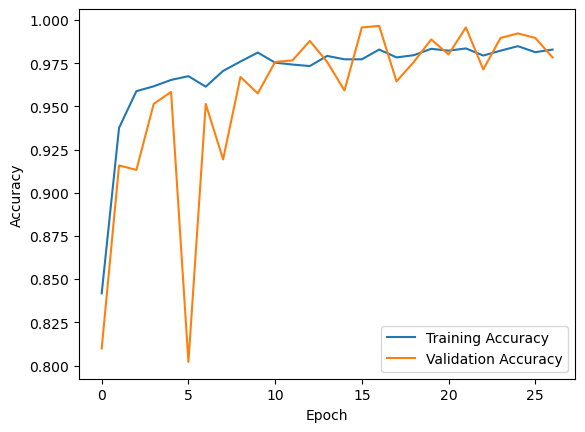

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1000, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 1000, 128)      │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1000, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1000, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 64000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │     2,048,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,248,325 (23.84 MB)

 Trainable params: 2,082,625 (7.94 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 4,165,252 (15.89 MB)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       568
           1       1.00      0.99      1.00       872

    accuracy                           1.00      1440
   macro avg       0.99      1.00      0.99      1440
weighted avg       1.00      1.00      1.00      1440



In [3]:
#IMPLEMENTING NORMALIZATION OF DATA WITH HIGHER EPOCHS AND EARLY STOPPING
import os
import numpy as np
import pandas as pd
from scipy.fft import fft
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, Dense, Flatten, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

def process_file(file_path, data_segments, labels, label, segment_count, segment_length=1000):
    """
    Process a single file: split into segments, apply FFT, and assign labels.
    """
    try:
        # Load the CSV file
        df = pd.read_csv(file_path, header=None)
        current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

        # Split into 1-second segments (1000 samples per segment)
        segments = [current_data[i:i + segment_length] for i in range(0, len(current_data), segment_length) if i + segment_length <= len(current_data)]

        # Perform FFT on each segment and keep the shape as (segment_length, 3)
        for segment in segments:
            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT to each phase (R, Y, B)
            data_segments.append(fft_result)  # Shape: (segment_length, 3)
            labels.append(label)
            segment_count[label] += 1  # Increment the count for the respective label

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
    
    return data_segments, labels, segment_count

def load_and_preprocess_data(data_dir, segment_length=1000):
    """
    Load and preprocess data from the directory.
    """
    data_segments = []
    labels = []
    segment_count = {0: 0, 1: 0}  # Count of segments for No_Fault (0) and Fault (1)
    file_count = 0  # Initialize file counter

    # Iterate over load levels (e.g., 0.5_A, 1_A, etc.)
    for load in os.listdir(data_dir):
        load_path = os.path.join(data_dir, load)
        if not os.path.isdir(load_path):
            continue

        # Check for Fault and No_Fault directories
        for condition in ["Fault", "No_Fault"]:
            condition_path = os.path.join(load_path, condition)
            if condition == "Fault":  # Handle fault conditions
                for phase in ["P2"]:  # Only process P1 for this NN
                    phase_path = os.path.join(condition_path, phase)
                    if os.path.exists(phase_path):
                        for file in os.listdir(phase_path):
                            if file.endswith(".csv"):
                                file_count += 1  # Increment the file counter
                                file_path = os.path.join(phase_path, file)
                                data_segments, labels, segment_count = process_file(file_path, data_segments, labels, label=1, segment_count=segment_count, segment_length=segment_length)
            elif condition == "No_Fault":  # Handle no fault conditions
                if os.path.exists(condition_path):
                    for file in os.listdir(condition_path):
                        if file.endswith(".csv"):
                            file_count += 1  # Increment the file counter
                            file_path = os.path.join(condition_path, file)
                            data_segments, labels, segment_count = process_file(file_path, data_segments, labels, label=0, segment_count=segment_count, segment_length=segment_length)

    print(f"Total files processed: {file_count}")  # Print the total file count
    print(f"Total FFT segments for Fault: {segment_count[1]}")
    print(f"Total FFT segments for No Fault: {segment_count[0]}")
    return np.array(data_segments), np.array(labels)

# Directory path to data
base_dir = "/home/ani/DataNN/5kVA/Load"

# Load and preprocess data with 1-second intervals (1000 samples per segment)
segment_length = 1000  # Change to 500 if you want 500 samples per segment
data, labels = load_and_preprocess_data(base_dir, segment_length=segment_length)

# Check if data was loaded
if data.size == 0:
    print("No data found! Check the directory structure and file paths.")
    exit()

# Normalize data
#data = (data - np.min(data)) / (np.max(data) - np.min(data))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Print training and testing FFT segment counts
print(f"Training FFT segments: {len(X_train)}")
print(f"Testing FFT segments: {len(X_test)}")

# Check class distribution
print(f"Class 0 (Healthy) samples: {np.sum(labels == 0)}")
print(f"Class 1 (Faulty) samples: {np.sum(labels == 1)}")

# Define the CNN model with a bottleneck layer
def build_cnn_model(input_shape):
    inputs = Input(shape=input_shape)

    # Convolutional layers
    x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Increased dropout rate

    x = Conv1D(64, kernel_size=4, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Increased dropout rate

    x = Flatten()(x)

    # Bottleneck layer
    x = Dense(32)(x)  # Bottleneck size = 32
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Increased dropout rate
    x = Activation('relu')(x)

    # Output layer
    outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Build the model
input_shape = (segment_length, 3)  # Input shape: (segment_length, 3)
cnn_model = build_cnn_model(input_shape)

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Add early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with early stopping
history = cnn_model.fit(
    X_train, y_train,
    epochs=50,  # Increased epochs
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping]
)

# Evaluate the model
loss, accuracy = cnn_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training history
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
cnn_model.summary()
# Additional evaluation
y_pred = (cnn_model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Total files processed: 720
Total FFT segments for Fault: 4320
Total FFT segments for No Fault: 2880
Training FFT segments: 5760
Testing FFT segments: 1440
Class 0 (Healthy) samples: 2880
Class 1 (Faulty) samples: 4320
Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6188 - loss: 0.7083 - val_accuracy: 0.5920 - val_loss: 0.9702
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7736 - loss: 0.4636 - val_accuracy: 0.5920 - val_loss: 0.7442
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9110 - loss: 0.2342 - val_accuracy: 0.5920 - val_loss: 0.6606
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9421 - loss: 0.1750 - val_accuracy: 0.8724 - val_loss: 0.4100
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9507 - loss: 0.1501 - val_accuracy: 0.9123 - val_loss: 0.2867
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9532 - loss: 0.1293 - val_accuracy: 0.5929 - val_loss: 0.8654
Epoch 7/50
144

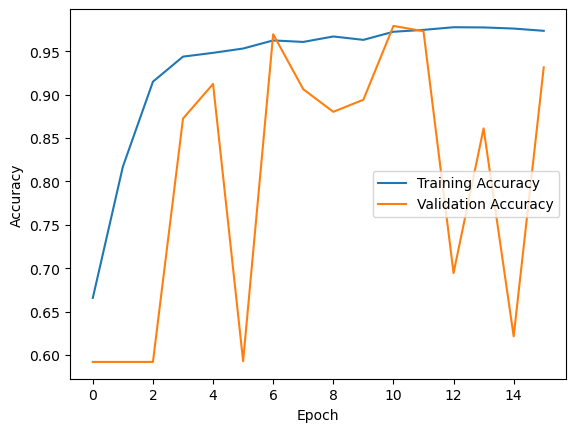

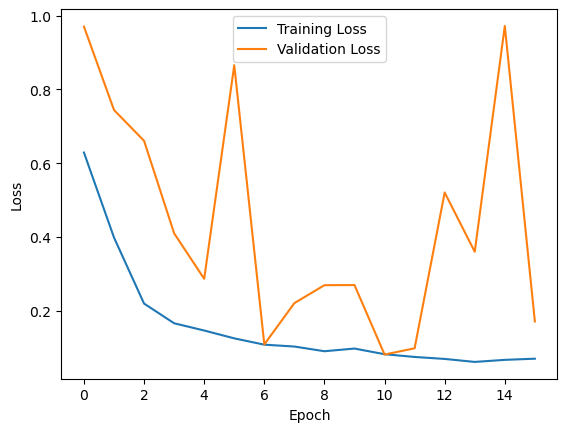

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1000, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 1000, 128)      │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1000, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 1000, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 64000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │     2,048,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,248,325 (23.84 MB)

 Trainable params: 2,082,625 (7.94 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 4,165,252 (15.89 MB)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       568
           1       1.00      0.96      0.98       872

    accuracy                           0.97      1440
   macro avg       0.97      0.98      0.97      1440
weighted avg       0.98      0.97      0.97      1440



In [4]:
#IMPLEMENTING WEIGHTS FOR IMBALANCED DATA
import os
import numpy as np
import pandas as pd
from scipy.fft import fft
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, Dense, Flatten, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

def process_file(file_path, data_segments, labels, label, segment_count, segment_length=1000):
    """
    Process a single file: split into segments, apply FFT, and assign labels.
    """
    try:
        # Load the CSV file
        df = pd.read_csv(file_path, header=None)
        current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

        # Split into 1-second segments (1000 samples per segment)
        segments = [current_data[i:i + segment_length] for i in range(0, len(current_data), segment_length) if i + segment_length <= len(current_data)]

        # Perform FFT on each segment and keep the shape as (segment_length, 3)
        for segment in segments:
            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT to each phase (R, Y, B)
            data_segments.append(fft_result)  # Shape: (segment_length, 3)
            labels.append(label)
            segment_count[label] += 1  # Increment the count for the respective label

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
    
    return data_segments, labels, segment_count

def load_and_preprocess_data(data_dir, segment_length=1000):
    """
    Load and preprocess data from the directory.
    """
    data_segments = []
    labels = []
    segment_count = {0: 0, 1: 0}  # Count of segments for No_Fault (0) and Fault (1)
    file_count = 0  # Initialize file counter

    # Iterate over load levels (e.g., 0.5_A, 1_A, etc.)
    for load in os.listdir(data_dir):
        load_path = os.path.join(data_dir, load)
        if not os.path.isdir(load_path):
            continue

        # Check for Fault and No_Fault directories
        for condition in ["Fault", "No_Fault"]:
            condition_path = os.path.join(load_path, condition)
            if condition == "Fault":  # Handle fault conditions
                for phase in ["P2"]:  # Only process P1 for this NN
                    phase_path = os.path.join(condition_path, phase)
                    if os.path.exists(phase_path):
                        for file in os.listdir(phase_path):
                            if file.endswith(".csv"):
                                file_count += 1  # Increment the file counter
                                file_path = os.path.join(phase_path, file)
                                data_segments, labels, segment_count = process_file(file_path, data_segments, labels, label=1, segment_count=segment_count, segment_length=segment_length)
            elif condition == "No_Fault":  # Handle no fault conditions
                if os.path.exists(condition_path):
                    for file in os.listdir(condition_path):
                        if file.endswith(".csv"):
                            file_count += 1  # Increment the file counter
                            file_path = os.path.join(condition_path, file)
                            data_segments, labels, segment_count = process_file(file_path, data_segments, labels, label=0, segment_count=segment_count, segment_length=segment_length)

    print(f"Total files processed: {file_count}")  # Print the total file count
    print(f"Total FFT segments for Fault: {segment_count[1]}")
    print(f"Total FFT segments for No Fault: {segment_count[0]}")
    return np.array(data_segments), np.array(labels)

# Directory path to data
base_dir = "/home/ani/DataNN/5kVA/Load"

# Load and preprocess data with 1-second intervals (1000 samples per segment)
segment_length = 1000  # Change to 500 if you want 500 samples per segment
data, labels = load_and_preprocess_data(base_dir, segment_length=segment_length)

# Check if data was loaded
if data.size == 0:
    print("No data found! Check the directory structure and file paths.")
    exit()

# Normalize data
data = (data - np.min(data)) / (np.max(data) - np.min(data))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Print training and testing FFT segment counts
print(f"Training FFT segments: {len(X_train)}")
print(f"Testing FFT segments: {len(X_test)}")

# Check class distribution
print(f"Class 0 (Healthy) samples: {np.sum(labels == 0)}")
print(f"Class 1 (Faulty) samples: {np.sum(labels == 1)}")

# Define the CNN model with a bottleneck layer
def build_cnn_model(input_shape):
    inputs = Input(shape=input_shape)

    # Convolutional layers
    x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Conv1D(64, kernel_size=4, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Flatten()(x)

    # Bottleneck layer
    x = Dense(32)(x)  # Bottleneck size = 32
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting
    x = Activation('relu')(x)

    # Output layer
    outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Build the model
input_shape = (segment_length, 3)  # Input shape: (segment_length, 3)
cnn_model = build_cnn_model(input_shape)

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Add early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Add class weighting to address imbalance
class_weights = {0: 1.2, 1: 0.8}  # Adjust weights based on class imbalance

# Train the model with early stopping and class weighting
history = cnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    class_weight=class_weights
)

# Evaluate the model
loss, accuracy = cnn_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
cnn_model.summary()
# Additional evaluation
y_pred = (cnn_model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Total files processed: 720
Total FFT segments for Fault: 4320
Total FFT segments for No Fault: 2880
Training FFT segments: 5760
Testing FFT segments: 1440
Class 0 (Healthy) samples in training: 2304
Class 1 (Faulty) samples in training: 3456
Class 0 (Healthy) samples in testing: 576
Class 1 (Faulty) samples in testing: 864
Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7565 - loss: 0.4733 - val_accuracy: 0.7170 - val_loss: 0.5066
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9232 - loss: 0.1849 - val_accuracy: 0.7543 - val_loss: 0.4824
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9575 - loss: 0.1255 - val_accuracy: 0.9714 - val_loss: 0.1005
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9579 - loss: 0.1235 - val_accuracy: 0.9618 - val_loss: 0.1163
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9569 - loss: 0.1063 - val_accuracy: 0.9583 - val_loss: 0.1307
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━

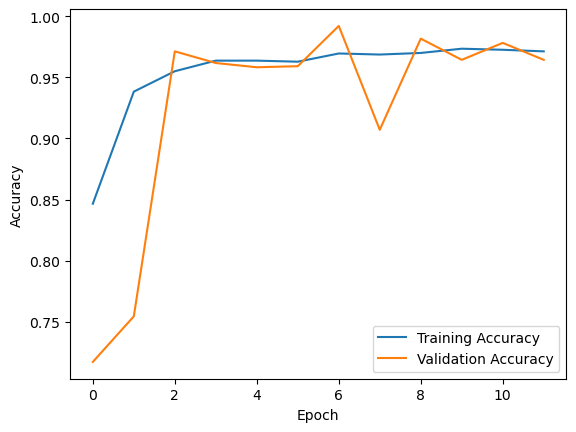

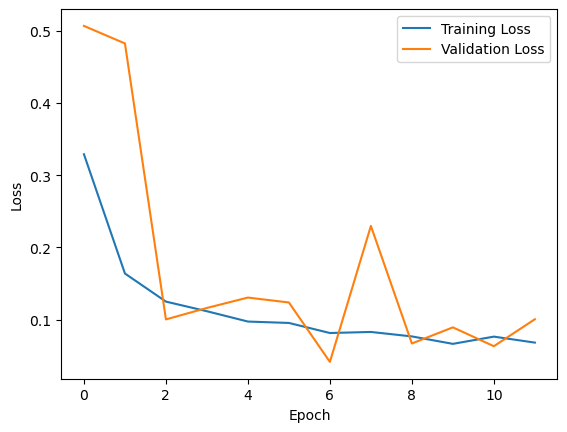

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 1000, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 1000, 128)      │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1000, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 1000, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 1000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 64000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │     2,048,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,248,325 (23.84 MB)

 Trainable params: 2,082,625 (7.94 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 4,165,252 (15.89 MB)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       576
           1       1.00      0.98      0.99       864

    accuracy                           0.99      1440
   macro avg       0.99      0.99      0.99      1440
weighted avg       0.99      0.99      0.99      1440



In [5]:
#TRAINING OF THE CONVOLUTIONAL NN MODEL SEPARATED TRAINTESTSPLIT FOR FAULT NO FAULT
import os
import numpy as np
import pandas as pd
from scipy.fft import fft
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, Dense, Flatten, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

def process_file(file_path, data_segments, labels, label, segment_length=1000):
    """
    Process a single file: split into segments, apply FFT, and assign labels.
    """
    try:
        # Load the CSV file
        df = pd.read_csv(file_path, header=None)
        current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

        # Split into 1-second segments (1000 samples per segment)
        segments = [current_data[i:i + segment_length] for i in range(0, len(current_data), segment_length) if i + segment_length <= len(current_data)]

        # Perform FFT on each segment and keep the shape as (segment_length, 3)
        for segment in segments:
            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT to each phase (R, Y, B)
            data_segments.append(fft_result)  # Shape: (segment_length, 3)
            labels.append(label)

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
    
    return data_segments, labels

def load_and_preprocess_data(data_dir, segment_length=1000, test_size=0.2, random_state=42):
    """
    Load and preprocess data from the directory, splitting fault and no-fault data separately.
    """
    fault_data = []
    no_fault_data = []
    fault_labels = []
    no_fault_labels = []
    file_count = 0  # Initialize file counter

    # Iterate over load levels (e.g., 0.5_A, 1_A, etc.)
    for load in os.listdir(data_dir):
        load_path = os.path.join(data_dir, load)
        if not os.path.isdir(load_path):
            continue

        # Check for Fault and No_Fault directories
        for condition in ["Fault", "No_Fault"]:
            condition_path = os.path.join(load_path, condition)
            if condition == "Fault":  # Handle fault conditions
                for phase in ["P2"]:  # Only process P1 for this NN
                    phase_path = os.path.join(condition_path, phase)
                    if os.path.exists(phase_path):
                        for file in os.listdir(phase_path):
                            if file.endswith(".csv"):
                                file_count += 1  # Increment the file counter
                                file_path = os.path.join(phase_path, file)
                                fault_data, fault_labels = process_file(file_path, fault_data, fault_labels, label=1, segment_length=segment_length)
            elif condition == "No_Fault":  # Handle no fault conditions
                if os.path.exists(condition_path):
                    for file in os.listdir(condition_path):
                        if file.endswith(".csv"):
                            file_count += 1  # Increment the file counter
                            file_path = os.path.join(condition_path, file)
                            no_fault_data, no_fault_labels = process_file(file_path, no_fault_data, no_fault_labels, label=0, segment_length=segment_length)

    print(f"Total files processed: {file_count}")  # Print the total file count
    print(f"Total FFT segments for Fault: {len(fault_data)}")
    print(f"Total FFT segments for No Fault: {len(no_fault_data)}")

    # Convert to numpy arrays
    fault_data = np.array(fault_data)
    no_fault_data = np.array(no_fault_data)
    fault_labels = np.array(fault_labels)
    no_fault_labels = np.array(no_fault_labels)

    # Split fault data into train and test sets
    X_fault_train, X_fault_test, y_fault_train, y_fault_test = train_test_split(
        fault_data, fault_labels, test_size=test_size, random_state=random_state
    )

    # Split no-fault data into train and test sets
    X_no_fault_train, X_no_fault_test, y_no_fault_train, y_no_fault_test = train_test_split(
        no_fault_data, no_fault_labels, test_size=test_size, random_state=random_state
    )

    # Combine fault and no-fault data
    X_train = np.concatenate((X_fault_train, X_no_fault_train), axis=0)
    X_test = np.concatenate((X_fault_test, X_no_fault_test), axis=0)
    y_train = np.concatenate((y_fault_train, y_no_fault_train), axis=0)
    y_test = np.concatenate((y_fault_test, y_no_fault_test), axis=0)

    # Shuffle the training and testing data
    train_indices = np.arange(len(X_train))
    test_indices = np.arange(len(X_test))
    np.random.shuffle(train_indices)
    np.random.shuffle(test_indices)

    X_train = X_train[train_indices]
    y_train = y_train[train_indices]
    X_test = X_test[test_indices]
    y_test = y_test[test_indices]

    return X_train, X_test, y_train, y_test

# Directory path to data
base_dir = "/home/ani/DataNN/5kVA/Load"

# Load and preprocess data with 1-second intervals (1000 samples per segment)
segment_length = 1000  # Change to 500 if you want 500 samples per segment
X_train, X_test, y_train, y_test = load_and_preprocess_data(base_dir, segment_length=segment_length)

# Check if data was loaded
if X_train.size == 0 or X_test.size == 0:
    print("No data found! Check the directory structure and file paths.")
    exit()

# Print training and testing FFT segment counts
print(f"Training FFT segments: {len(X_train)}")
print(f"Testing FFT segments: {len(X_test)}")

# Check class distribution
print(f"Class 0 (Healthy) samples in training: {np.sum(y_train == 0)}")
print(f"Class 1 (Faulty) samples in training: {np.sum(y_train == 1)}")
print(f"Class 0 (Healthy) samples in testing: {np.sum(y_test == 0)}")
print(f"Class 1 (Faulty) samples in testing: {np.sum(y_test == 1)}")

# Define the CNN model with a bottleneck layer
def build_cnn_model(input_shape):
    inputs = Input(shape=input_shape)

    # Convolutional layers
    x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Conv1D(64, kernel_size=4, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Flatten()(x)

    # Bottleneck layer
    x = Dense(32)(x)  # Bottleneck size = 32
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting
    x = Activation('relu')(x)

    # Output layer
    outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Build the model
input_shape = (segment_length, 3)  # Input shape: (segment_length, 3)
cnn_model = build_cnn_model(input_shape)

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Add early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Add class weighting to address imbalance
class_weights = {0: 1.2, 1: 0.8}  # Adjust weights based on class imbalance

# Train the model with early stopping and class weighting
history = cnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    class_weight=class_weights
)

# Evaluate the model
loss, accuracy = cnn_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
cnn_model.summary()
# Additional evaluation
y_pred = (cnn_model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Total files processed: 720
Total FFT segments for Fault: 4320
Total FFT segments for No Fault: 2880
Training FFT segments: 5760
Testing FFT segments: 647
Class 0 (Healthy) samples in training: 2304
Class 1 (Faulty) samples in training: 3456
Class 0 (Healthy) samples in testing: 576
Class 1 (Faulty) samples in testing: 71
Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7552 - loss: 0.4965 - val_accuracy: 0.7283 - val_loss: 0.4917
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9266 - loss: 0.2003 - val_accuracy: 0.9479 - val_loss: 0.1754
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9432 - loss: 0.1466 - val_accuracy: 0.9722 - val_loss: 0.0995
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9665 - loss: 0.1019 - val_accuracy: 0.9861 - val_loss: 0.0814
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9566 - loss: 0.1067 - val_accuracy: 0.9826 - val_loss: 0.0584
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━

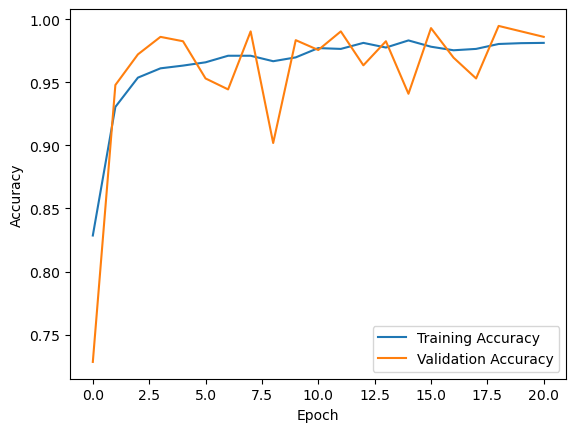

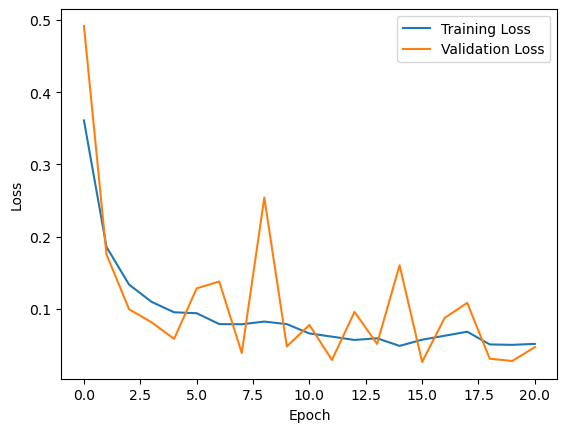

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 1000, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 1000, 128)      │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 1000, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 1000, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 64000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │     2,048,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,248,325 (23.84 MB)

 Trainable params: 2,082,625 (7.94 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 4,165,252 (15.89 MB)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       576
           1       0.90      0.27      0.41        71

    accuracy                           0.92       647
   macro avg       0.91      0.63      0.68       647
weighted avg       0.92      0.92      0.90       647



In [6]:
#TESTING INTERMITTENT FAULT NO PROCESSING
import os
import numpy as np
import pandas as pd
from scipy.fft import fft
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, Dense, Flatten, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

def process_file(file_path, data_segments, labels, label, segment_length=1000):
    """
    Process a single file: split into segments, apply FFT, and assign labels.
    """
    try:
        # Load the CSV file
        df = pd.read_csv(file_path, header=None)
        current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

        # Split into 1-second segments (1000 samples per segment)
        segments = [current_data[i:i + segment_length] for i in range(0, len(current_data), segment_length) if i + segment_length <= len(current_data)]

        # Perform FFT on each segment and keep the shape as (segment_length, 3)
        for segment in segments:
            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT to each phase (R, Y, B)
            data_segments.append(fft_result)  # Shape: (segment_length, 3)
            labels.append(label)

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
    
    return data_segments, labels

def load_intermittent_fault_data(base_dir, segment_length=1000):
    """
    Load intermittent fault data from the specified directory and extract windows.
    """
    intermittent_data = []
    intermittent_labels = []

    # Define window extraction logic for each folder
    window_rules = {
        "0.2s": [(1000, 2000)],  # 1s to 2s
        "0.5s": [(1000, 2000)],  # 1s to 2s
        "1s": [(600, 1600), (1600, 2600)],  # 0.6s to 1.6s and 1.6s to 2.6s
        "2s": [(600, 1600), (2400, 3400)],  # 0.6s to 1.6s and 2.4s to 3.4s
    }

    for folder, windows in window_rules.items():
        folder_path = os.path.join(base_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Folder {folder_path} does not exist. Skipping.")
            continue

        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)
                try:
                    # Load the CSV file
                    df = pd.read_csv(file_path, header=None)
                    current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

                    # Extract the specified windows
                    for start, end in windows:
                        segment = current_data[start:end]
                        if len(segment) == segment_length:
                            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT
                            intermittent_data.append(fft_result)
                            intermittent_labels.append(1)  # Label for fault

                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")

    return np.array(intermittent_data), np.array(intermittent_labels)

def load_and_preprocess_data(data_dir, segment_length=1000, test_size=0.2, random_state=42):
    """
    Load and preprocess data from the directory, splitting fault and no-fault data separately.
    """
    fault_data = []
    no_fault_data = []
    fault_labels = []
    no_fault_labels = []
    file_count = 0  # Initialize file counter

    # Iterate over load levels (e.g., 0.5_A, 1_A, etc.)
    for load in os.listdir(data_dir):
        load_path = os.path.join(data_dir, load)
        if not os.path.isdir(load_path):
            continue

        # Check for Fault and No_Fault directories
        for condition in ["Fault", "No_Fault"]:
            condition_path = os.path.join(load_path, condition)
            if condition == "Fault":  # Handle fault conditions
                for phase in ["P2"]:  # Only process P1 for this NN
                    phase_path = os.path.join(condition_path, phase)
                    if os.path.exists(phase_path):
                        for file in os.listdir(phase_path):
                            if file.endswith(".csv"):
                                file_count += 1  # Increment the file counter
                                file_path = os.path.join(phase_path, file)
                                fault_data, fault_labels = process_file(file_path, fault_data, fault_labels, label=1, segment_length=segment_length)
            elif condition == "No_Fault":  # Handle no fault conditions
                if os.path.exists(condition_path):
                    for file in os.listdir(condition_path):
                        if file.endswith(".csv"):
                            file_count += 1  # Increment the file counter
                            file_path = os.path.join(condition_path, file)
                            no_fault_data, no_fault_labels = process_file(file_path, no_fault_data, no_fault_labels, label=0, segment_length=segment_length)

    print(f"Total files processed: {file_count}")  # Print the total file count
    print(f"Total FFT segments for Fault: {len(fault_data)}")
    print(f"Total FFT segments for No Fault: {len(no_fault_data)}")

    # Convert to numpy arrays
    fault_data = np.array(fault_data)
    no_fault_data = np.array(no_fault_data)
    fault_labels = np.array(fault_labels)
    no_fault_labels = np.array(no_fault_labels)

    # Split fault data into train and test sets
    X_fault_train, _, y_fault_train, _ = train_test_split(
        fault_data, fault_labels, test_size=test_size, random_state=random_state
    )

    # Split no-fault data into train and test sets
    X_no_fault_train, X_no_fault_test, y_no_fault_train, y_no_fault_test = train_test_split(
        no_fault_data, no_fault_labels, test_size=test_size, random_state=random_state
    )

    # Load intermittent fault data for testing
    intermittent_fault_dir = "/home/ani/Project/Interfault/Y/"
    X_intermittent_fault, y_intermittent_fault = load_intermittent_fault_data(intermittent_fault_dir, segment_length=segment_length)

    # Combine fault and no-fault data for training
    X_train = np.concatenate((X_fault_train, X_no_fault_train), axis=0)
    y_train = np.concatenate((y_fault_train, y_no_fault_train), axis=0)

    # Use intermittent fault data and no-fault test data for testing
    X_test = np.concatenate((X_intermittent_fault, X_no_fault_test), axis=0)
    y_test = np.concatenate((y_intermittent_fault, y_no_fault_test), axis=0)

    # Shuffle the training and testing data
    train_indices = np.arange(len(X_train))
    test_indices = np.arange(len(X_test))
    np.random.shuffle(train_indices)
    np.random.shuffle(test_indices)

    X_train = X_train[train_indices]
    y_train = y_train[train_indices]
    X_test = X_test[test_indices]
    y_test = y_test[test_indices]

    return X_train, X_test, y_train, y_test

# Directory path to data
base_dir = "/home/ani/DataNN/5kVA/Load"

# Load and preprocess data with 1-second intervals (1000 samples per segment)
segment_length = 1000  # Change to 500 if you want 500 samples per segment
X_train, X_test, y_train, y_test = load_and_preprocess_data(base_dir, segment_length=segment_length)

# Check if data was loaded
if X_train.size == 0 or X_test.size == 0:
    print("No data found! Check the directory structure and file paths.")
    exit()

# Print training and testing FFT segment counts
print(f"Training FFT segments: {len(X_train)}")
print(f"Testing FFT segments: {len(X_test)}")

# Check class distribution
print(f"Class 0 (Healthy) samples in training: {np.sum(y_train == 0)}")
print(f"Class 1 (Faulty) samples in training: {np.sum(y_train == 1)}")
print(f"Class 0 (Healthy) samples in testing: {np.sum(y_test == 0)}")
print(f"Class 1 (Faulty) samples in testing: {np.sum(y_test == 1)}")

# Define the CNN model with a bottleneck layer
def build_cnn_model(input_shape):
    inputs = Input(shape=input_shape)

    # Convolutional layers
    x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Conv1D(64, kernel_size=4, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Flatten()(x)

    # Bottleneck layer
    x = Dense(32)(x)  # Bottleneck size = 32
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting
    x = Activation('relu')(x)

    # Output layer
    outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Build the model
input_shape = (segment_length, 3)  # Input shape: (segment_length, 3)
cnn_model = build_cnn_model(input_shape)

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Add early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Add class weighting to address imbalance
class_weights = {0: 1.2, 1: 0.8}  # Adjust weights based on class imbalance

# Train the model with early stopping and class weighting
history = cnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    class_weight=class_weights
)

# Evaluate the model
loss, accuracy = cnn_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
cnn_model.summary()
# Additional evaluation
y_pred = (cnn_model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Plotting STFT for 0.2s...


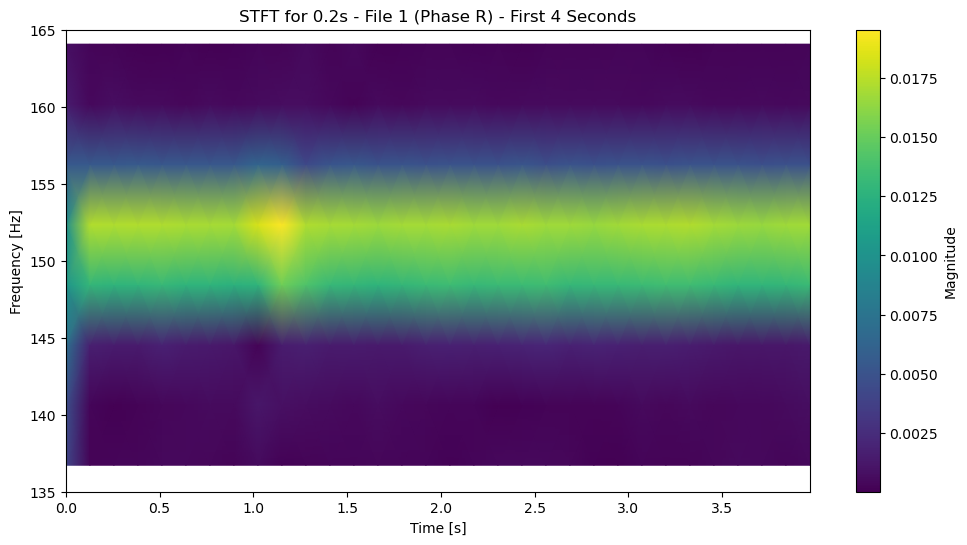

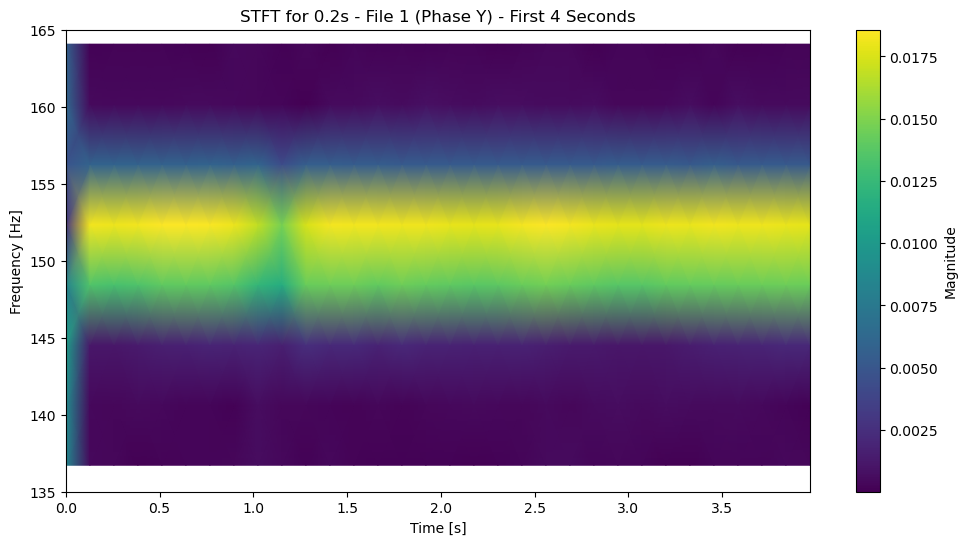

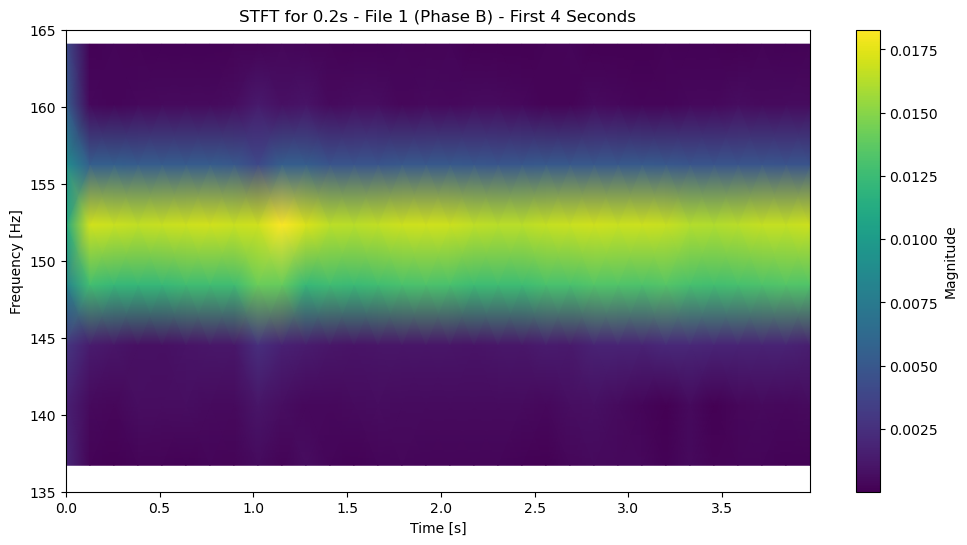

Plotting STFT for 0.5s...


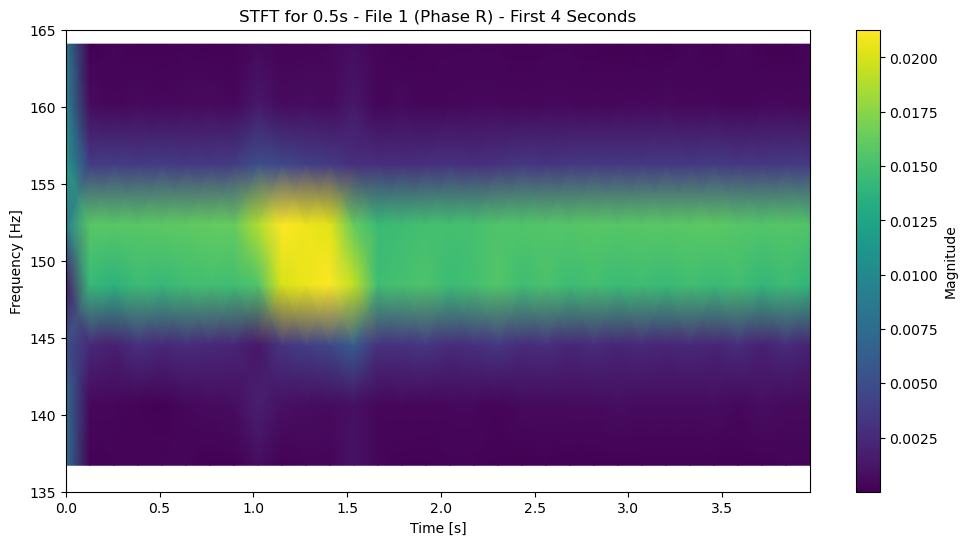

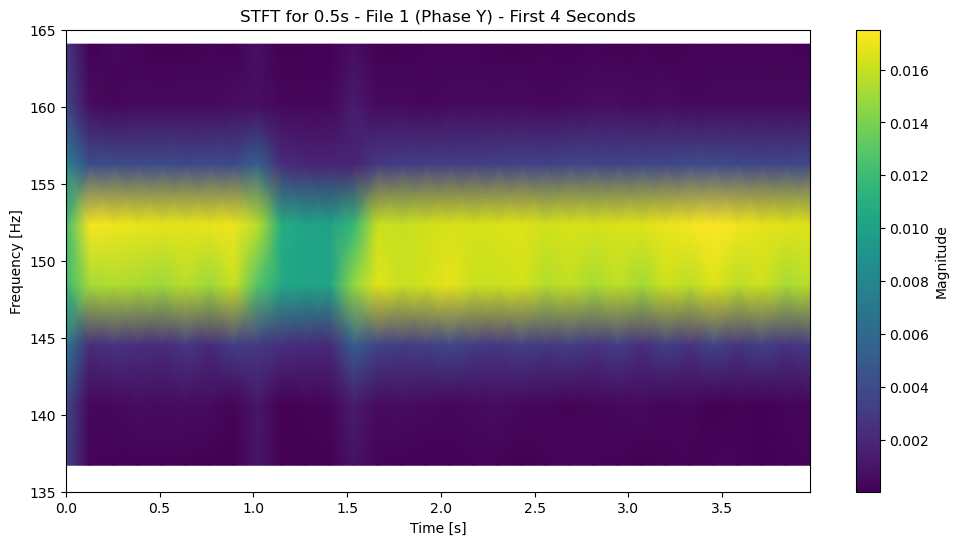

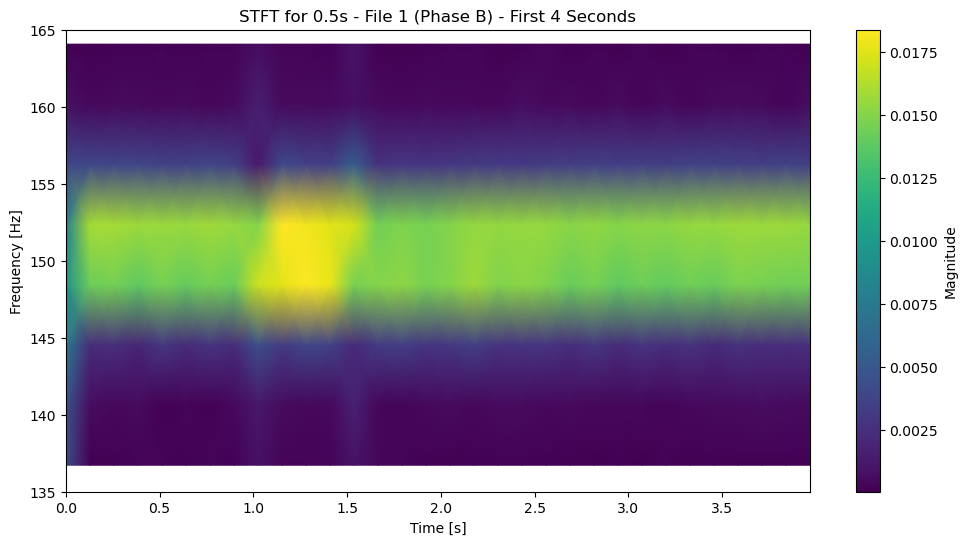

Plotting STFT for 1s...


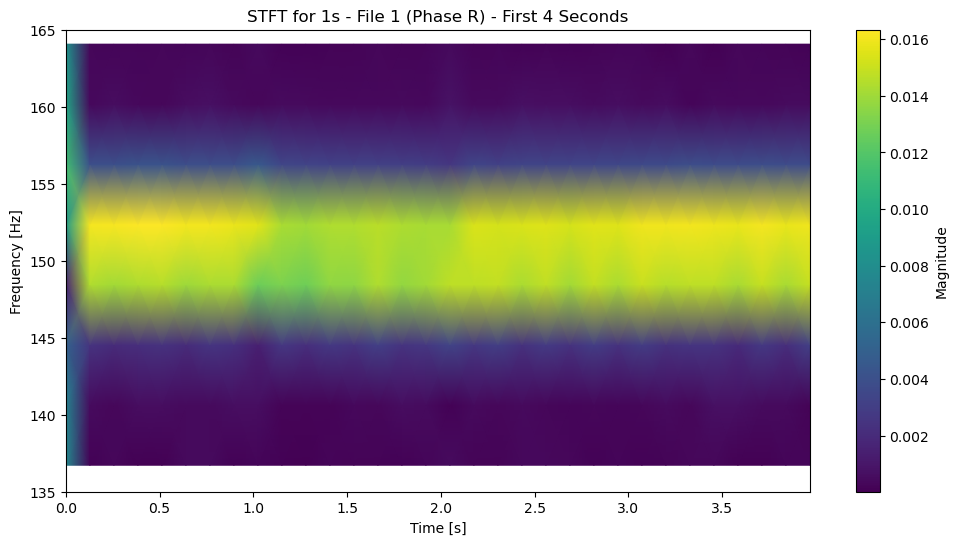

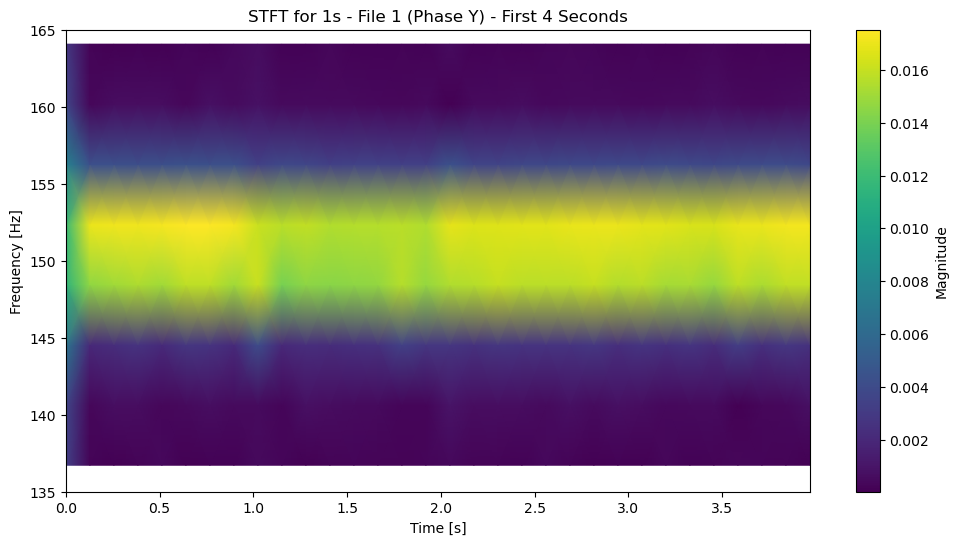

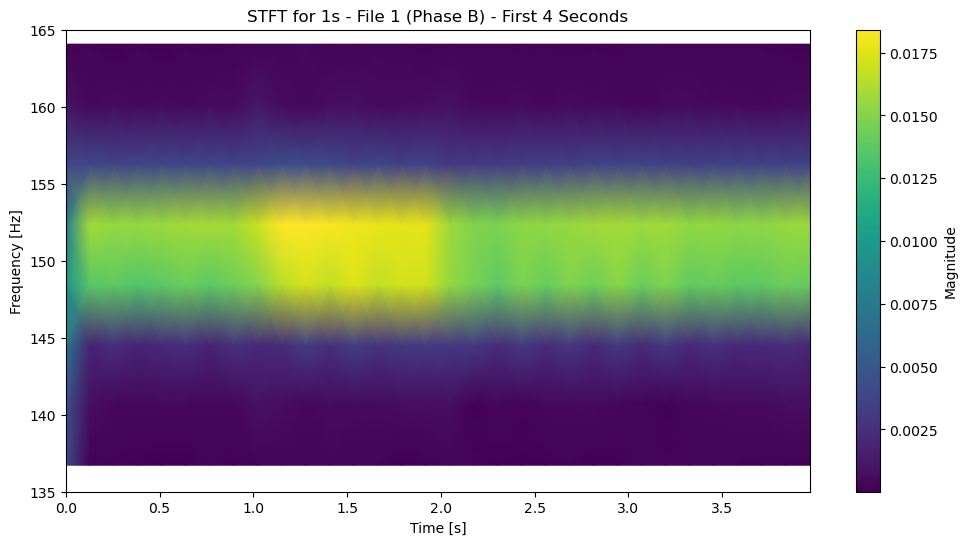

Plotting STFT for 2s...


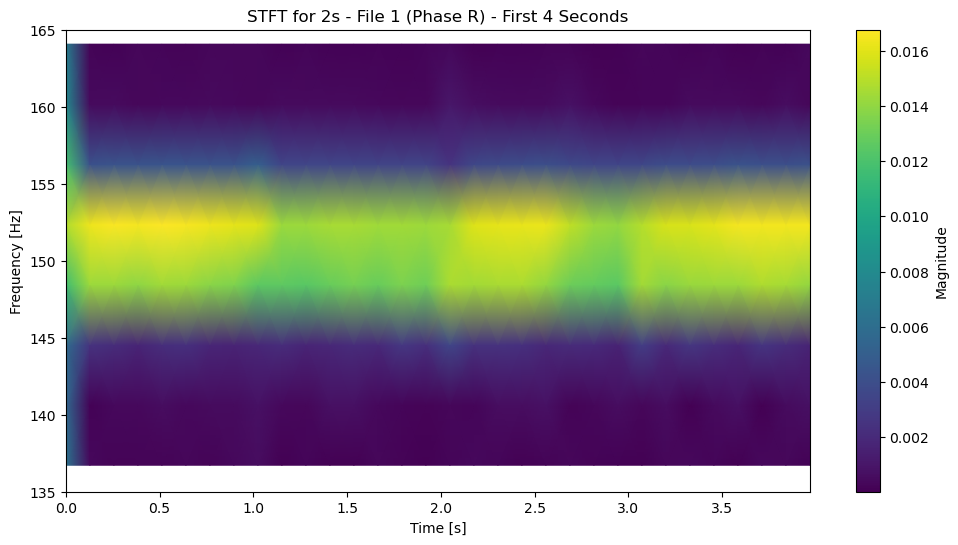

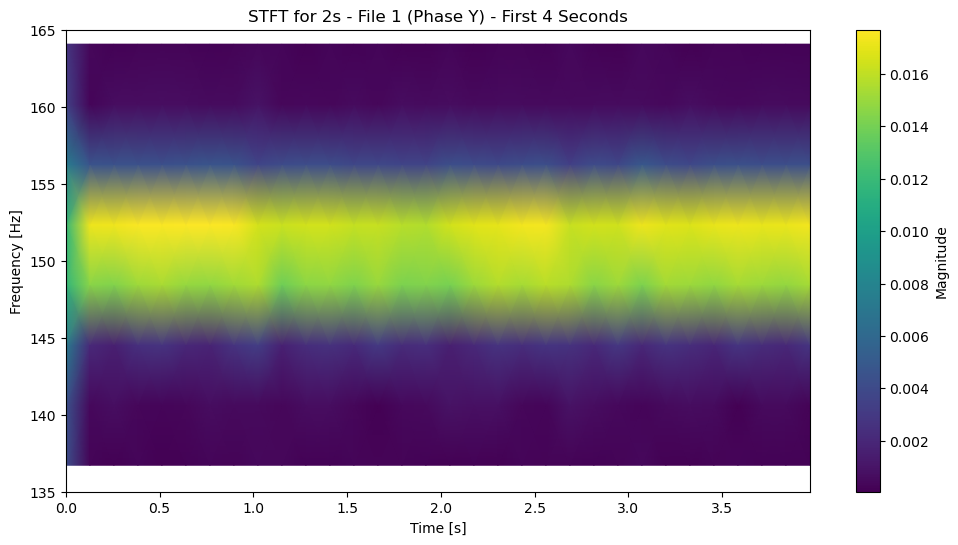

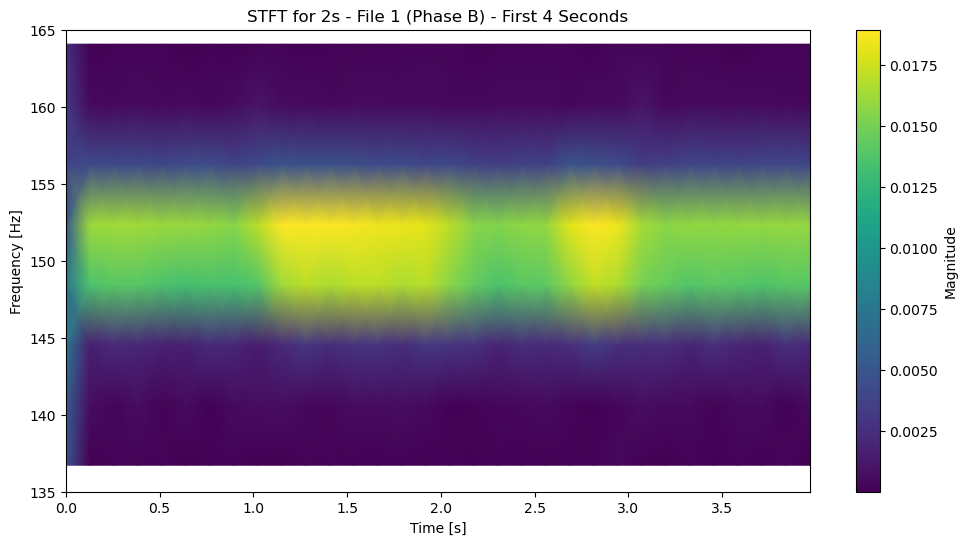

In [7]:
#PLOT FOR STFT
import os
import numpy as np
import pandas as pd
from scipy.signal import stft
import matplotlib.pyplot as plt

def load_intermittent_fault_data(base_dir):
    """
    Load intermittent fault data from the specified directory.
    """
    intermittent_data = {}
    folders = ["0.2s", "0.5s", "1s", "2s"]

    for folder in folders:
        folder_path = os.path.join(base_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Folder {folder_path} does not exist. Skipping.")
            continue

        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)
                try:
                    # Load the CSV file
                    df = pd.read_csv(file_path, header=None)
                    current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

                    if folder not in intermittent_data:
                        intermittent_data[folder] = []
                    intermittent_data[folder].append(current_data)

                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")

    return intermittent_data

def plot_stft(data, folder_name, file_name):
    """
    Compute and plot the STFT of the entire signal, zoomed in to the first 4 seconds and y-axis limited to 135–165 Hz.
    """
    # Compute STFT for each phase
    fs = 1000  # Sampling frequency (1 kHz)
    f, t, Zxx_R = stft(data[:, 0], fs=fs, nperseg=256, noverlap=128)
    _, _, Zxx_Y = stft(data[:, 1], fs=fs, nperseg=256, noverlap=128)
    _, _, Zxx_B = stft(data[:, 2], fs=fs, nperseg=256, noverlap=128)

    # Zoom in to the first 4 seconds
    zoom_time = 4  # Time limit in seconds
    zoom_index = np.where(t <= zoom_time)[0]  # Find indices for the first 4 seconds

    # Limit y-axis to 135–165 Hz
    freq_lower = 135  # Lower frequency limit in Hz
    freq_upper = 165  # Upper frequency limit in Hz
    freq_index = np.where((f >= freq_lower) & (f <= freq_upper))[0]  # Find indices for frequencies in 135–165 Hz

    # Plot STFT for Phase R
    plt.figure(figsize=(12, 6))
    plt.pcolormesh(t[zoom_index], f[freq_index], np.abs(Zxx_R[freq_index][:, zoom_index]), shading='gouraud')
    plt.title(f"STFT for {folder_name} - {file_name} (Phase R) - First 4 Seconds")
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [Hz]")
    plt.ylim(freq_lower, freq_upper)  # Set y-axis limit
    plt.colorbar(label="Magnitude")
    plt.show()

    # Plot STFT for Phase Y
    plt.figure(figsize=(12, 6))
    plt.pcolormesh(t[zoom_index], f[freq_index], np.abs(Zxx_Y[freq_index][:, zoom_index]), shading='gouraud')
    plt.title(f"STFT for {folder_name} - {file_name} (Phase Y) - First 4 Seconds")
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [Hz]")
    plt.ylim(freq_lower, freq_upper)  # Set y-axis limit
    plt.colorbar(label="Magnitude")
    plt.show()

    # Plot STFT for Phase B
    plt.figure(figsize=(12, 6))
    plt.pcolormesh(t[zoom_index], f[freq_index], np.abs(Zxx_B[freq_index][:, zoom_index]), shading='gouraud')
    plt.title(f"STFT for {folder_name} - {file_name} (Phase B) - First 4 Seconds")
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [Hz]")
    plt.ylim(freq_lower, freq_upper)  # Set y-axis limit
    plt.colorbar(label="Magnitude")
    plt.show()

# Directory path to intermittent fault data
intermittent_fault_dir = "/home/ani/Project/Interfault/Y/"

# Load intermittent fault data
intermittent_data = load_intermittent_fault_data(intermittent_fault_dir)

# Check if data was loaded
if not intermittent_data:
    print("No intermittent fault data found! Check the directory structure and file paths.")
    exit()

# Plot STFT for 1 file per folder
for folder, data_list in intermittent_data.items():
    if data_list:  # Check if data exists for the folder
        print(f"Plotting STFT for {folder}...")
        file_name = "File 1"  # Only plot the first file
        plot_stft(data_list[0], folder, file_name)  # Use the first file in the folder

Total files processed: 720
Total FFT segments for Fault: 4320
Total FFT segments for No Fault: 2880
Training FFT segments: 5760
Testing FFT segments: 647
Class 0 (Healthy) samples in training: 2304
Class 1 (Faulty) samples in training: 3456
Class 0 (Healthy) samples in testing: 576
Class 1 (Faulty) samples in testing: 71
Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7280 - loss: 0.5048 - val_accuracy: 0.6962 - val_loss: 0.5215
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9260 - loss: 0.1987 - val_accuracy: 0.8750 - val_loss: 0.2860
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9574 - loss: 0.1285 - val_accuracy: 0.9809 - val_loss: 0.0886
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9673 - loss: 0.1011 - val_accuracy: 0.9731 - val_loss: 0.1152
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9740 - loss: 0.0825 - val_accuracy: 0.9887 - val_loss: 0.0755
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━

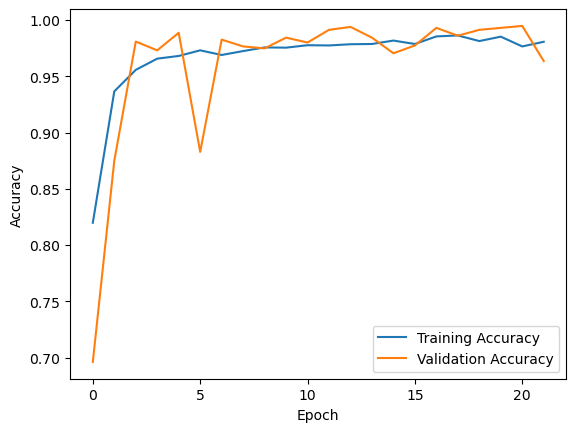

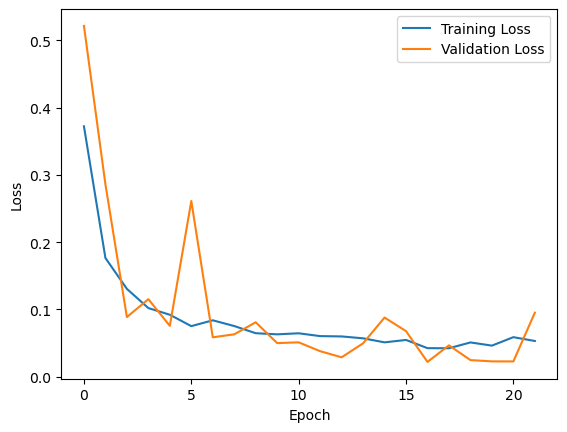

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 1000, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 1000, 128)      │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 1000, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 1000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 1000, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 1000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 1000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 64000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │     2,048,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,248,325 (23.84 MB)

 Trainable params: 2,082,625 (7.94 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 4,165,252 (15.89 MB)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       576
           1       0.95      1.00      0.97        71

    accuracy                           0.99       647
   macro avg       0.97      1.00      0.98       647
weighted avg       0.99      0.99      0.99       647



In [8]:
#TESTING INTERMITTENT FAULT WAVELET DB4
import os
import numpy as np
import pandas as pd
from scipy.fft import fft
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, Dense, Flatten, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

def process_file(file_path, data_segments, labels, label, segment_length=1000):
    """
    Process a single file: split into segments, apply FFT, and assign labels.
    """
    try:
        # Load the CSV file
        df = pd.read_csv(file_path, header=None)
        current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

        # Split into 1-second segments (1000 samples per segment)
        segments = [current_data[i:i + segment_length] for i in range(0, len(current_data), segment_length) if i + segment_length <= len(current_data)]

        # Perform FFT on each segment and keep the shape as (segment_length, 3)
        for segment in segments:
            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT to each phase (R, Y, B)
            data_segments.append(fft_result)  # Shape: (segment_length, 3)
            labels.append(label)

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
    
    return data_segments, labels

def load_intermittent_fault_data(base_dir, segment_length=1000):
    """
    Load intermittent fault data from the specified directory and extract windows.
    """
    intermittent_data = []
    intermittent_labels = []

    # Define window extraction logic for each folder
    window_rules = {
        "0.2s": [(1000, 2000)],  # 1s to 2s
        "0.5s": [(1000, 2000)],  # 1s to 2s
        "1s": [(600, 1600), (1600, 2600)],  # 0.6s to 1.6s and 1.6s to 2.6s
        "2s": [(600, 1600), (2400, 3400)],  # 0.6s to 1.6s and 2.4s to 3.4s
    }

    for folder, windows in window_rules.items():
        folder_path = os.path.join(base_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Folder {folder_path} does not exist. Skipping.")
            continue

        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)
                try:
                    # Load the CSV file
                    df = pd.read_csv(file_path, header=None)
                    current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

                    # Extract the specified windows
                    for start, end in windows:
                        segment = current_data[start:end]
                        if len(segment) == segment_length:
                            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT
                            intermittent_data.append(fft_result)
                            intermittent_labels.append(1)  # Label for fault

                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")

    return np.array(intermittent_data), np.array(intermittent_labels)

def load_and_preprocess_data(data_dir, segment_length=1000, test_size=0.2, random_state=42):
    """
    Load and preprocess data from the directory, splitting fault and no-fault data separately.
    """
    fault_data = []
    no_fault_data = []
    fault_labels = []
    no_fault_labels = []
    file_count = 0  # Initialize file counter

    # Iterate over load levels (e.g., 0.5_A, 1_A, etc.)
    for load in os.listdir(data_dir):
        load_path = os.path.join(data_dir, load)
        if not os.path.isdir(load_path):
            continue

        # Check for Fault and No_Fault directories
        for condition in ["Fault", "No_Fault"]:
            condition_path = os.path.join(load_path, condition)
            if condition == "Fault":  # Handle fault conditions
                for phase in ["P2"]:  # Only process P1 for this NN
                    phase_path = os.path.join(condition_path, phase)
                    if os.path.exists(phase_path):
                        for file in os.listdir(phase_path):
                            if file.endswith(".csv"):
                                file_count += 1  # Increment the file counter
                                file_path = os.path.join(phase_path, file)
                                fault_data, fault_labels = process_file(file_path, fault_data, fault_labels, label=1, segment_length=segment_length)
            elif condition == "No_Fault":  # Handle no fault conditions
                if os.path.exists(condition_path):
                    for file in os.listdir(condition_path):
                        if file.endswith(".csv"):
                            file_count += 1  # Increment the file counter
                            file_path = os.path.join(condition_path, file)
                            no_fault_data, no_fault_labels = process_file(file_path, no_fault_data, no_fault_labels, label=0, segment_length=segment_length)

    print(f"Total files processed: {file_count}")  # Print the total file count
    print(f"Total FFT segments for Fault: {len(fault_data)}")
    print(f"Total FFT segments for No Fault: {len(no_fault_data)}")

    # Convert to numpy arrays
    fault_data = np.array(fault_data)
    no_fault_data = np.array(no_fault_data)
    fault_labels = np.array(fault_labels)
    no_fault_labels = np.array(no_fault_labels)

    # Split fault data into train and test sets
    X_fault_train, _, y_fault_train, _ = train_test_split(
        fault_data, fault_labels, test_size=test_size, random_state=random_state
    )

    # Split no-fault data into train and test sets
    X_no_fault_train, X_no_fault_test, y_no_fault_train, y_no_fault_test = train_test_split(
        no_fault_data, no_fault_labels, test_size=test_size, random_state=random_state
    )

    # Load intermittent fault data for testing
    intermittent_fault_dir = "/home/ani/Project/Interfault_db4/Y/"
    X_intermittent_fault, y_intermittent_fault = load_intermittent_fault_data(intermittent_fault_dir, segment_length=segment_length)

    # Combine fault and no-fault data for training
    X_train = np.concatenate((X_fault_train, X_no_fault_train), axis=0)
    y_train = np.concatenate((y_fault_train, y_no_fault_train), axis=0)

    # Use intermittent fault data and no-fault test data for testing
    X_test = np.concatenate((X_intermittent_fault, X_no_fault_test), axis=0)
    y_test = np.concatenate((y_intermittent_fault, y_no_fault_test), axis=0)

    # Shuffle the training and testing data
    train_indices = np.arange(len(X_train))
    test_indices = np.arange(len(X_test))
    np.random.shuffle(train_indices)
    np.random.shuffle(test_indices)

    X_train = X_train[train_indices]
    y_train = y_train[train_indices]
    X_test = X_test[test_indices]
    y_test = y_test[test_indices]

    return X_train, X_test, y_train, y_test

# Directory path to data
base_dir = "/home/ani/DataNN/5kVA/Load"

# Load and preprocess data with 1-second intervals (1000 samples per segment)
segment_length = 1000  # Change to 500 if you want 500 samples per segment
X_train, X_test, y_train, y_test = load_and_preprocess_data(base_dir, segment_length=segment_length)

# Check if data was loaded
if X_train.size == 0 or X_test.size == 0:
    print("No data found! Check the directory structure and file paths.")
    exit()

# Print training and testing FFT segment counts
print(f"Training FFT segments: {len(X_train)}")
print(f"Testing FFT segments: {len(X_test)}")

# Check class distribution
print(f"Class 0 (Healthy) samples in training: {np.sum(y_train == 0)}")
print(f"Class 1 (Faulty) samples in training: {np.sum(y_train == 1)}")
print(f"Class 0 (Healthy) samples in testing: {np.sum(y_test == 0)}")
print(f"Class 1 (Faulty) samples in testing: {np.sum(y_test == 1)}")

# Define the CNN model with a bottleneck layer
def build_cnn_model(input_shape):
    inputs = Input(shape=input_shape)

    # Convolutional layers
    x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Conv1D(64, kernel_size=4, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Flatten()(x)

    # Bottleneck layer
    x = Dense(32)(x)  # Bottleneck size = 32
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting
    x = Activation('relu')(x)

    # Output layer
    outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Build the model
input_shape = (segment_length, 3)  # Input shape: (segment_length, 3)
cnn_model = build_cnn_model(input_shape)

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Add early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Add class weighting to address imbalance
class_weights = {0: 1.2, 1: 0.8}  # Adjust weights based on class imbalance

# Train the model with early stopping and class weighting
history = cnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    class_weight=class_weights
)

# Evaluate the model
loss, accuracy = cnn_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
cnn_model.summary()
# Additional evaluation
y_pred = (cnn_model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [9]:
#CNN Time Domain Data
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, Dense, Flatten, Activation
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report
from tensorflow.keras.models import Model

def process_file(file_path, data_segments, labels, label, segment_count, segment_length=1000):
    """
    Process a single file: split into segments and assign labels.
    """
    try:
        # Load the CSV file
        df = pd.read_csv(file_path, header=None)
        current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

        # Split into 1-second segments (1000 samples per segment)
        segments = [current_data[i:i + segment_length] for i in range(0, len(current_data), segment_length) if i + segment_length <= len(current_data)]

        # Append raw time-domain segments directly (no FFT)
        for segment in segments:
            data_segments.append(segment)  # Shape: (segment_length, 3)
            labels.append(label)
            segment_count[label] += 1  # Increment the count for the respective label

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
    
    return data_segments, labels, segment_count

def load_and_preprocess_data(data_dir, segment_length=1000):
    """
    Load and preprocess data from the directory.
    """
    data_segments = []
    labels = []
    segment_count = {0: 0, 1: 0}  # Count of segments for No_Fault (0) and Fault (1)
    file_count = 0  # Initialize file counter

    # Iterate over load levels (e.g., 0.5_A, 1_A, etc.)
    for load in os.listdir(data_dir):
        load_path = os.path.join(data_dir, load)
        if not os.path.isdir(load_path):
            continue

        # Check for Fault and No_Fault directories
        for condition in ["Fault", "No_Fault"]:
            condition_path = os.path.join(load_path, condition)
            if condition == "Fault":  # Handle fault conditions
                for phase in ["P1"]:  # Only process P1 for this NN
                    phase_path = os.path.join(condition_path, phase)
                    if os.path.exists(phase_path):
                        for file in os.listdir(phase_path):
                            if file.endswith(".csv"):
                                file_count += 1  # Increment the file counter
                                file_path = os.path.join(phase_path, file)
                                data_segments, labels, segment_count = process_file(file_path, data_segments, labels, label=1, segment_count=segment_count, segment_length=segment_length)
            elif condition == "No_Fault":  # Handle no fault conditions
                if os.path.exists(condition_path):
                    for file in os.listdir(condition_path):
                        if file.endswith(".csv"):
                            file_count += 1  # Increment the file counter
                            file_path = os.path.join(condition_path, file)
                            data_segments, labels, segment_count = process_file(file_path, data_segments, labels, label=0, segment_count=segment_count, segment_length=segment_length)

    print(f"Total files processed: {file_count}")  # Print the total file count
    print(f"Total segments for Fault: {segment_count[1]}")
    print(f"Total segments for No Fault: {segment_count[0]}")
    return np.array(data_segments), np.array(labels)

# Directory path to data
base_dir = "/home/ani/DataNN/5kVA/Load"

# Load and preprocess data with 1-second intervals (1000 samples per segment)
segment_length = 1000  # Change to 500 if you want 500 samples per segment
data, labels = load_and_preprocess_data(base_dir, segment_length=segment_length)

# Check if data was loaded
if data.size == 0:
    print("No data found! Check the directory structure and file paths.")
    exit()

# Normalize data
data = (data - np.min(data)) / (np.max(data) - np.min(data))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Print training and testing segment counts
print(f"Training segments: {len(X_train)}")
print(f"Testing segments: {len(X_test)}")

# Define the CNN model with a bottleneck layer
def build_cnn_model(input_shape):
    inputs = Input(shape=input_shape)

    # Only one convolutional layer
    x = Conv1D(32, kernel_size=3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    x = Flatten()(x)

    # Smaller bottleneck layer
    x = Dense(16)(x)  # Reduced bottleneck size
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Activation('relu')(x)

    # Output layer
    outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Build the simpler model
input_shape = (segment_length, 3)  # Input shape: (segment_length, 3)
cnn_model = build_cnn_model(input_shape)

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
cnn_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Build the model
input_shape = (segment_length, 3)  # Input shape: (segment_length, 3)
cnn_model = build_cnn_model(input_shape)

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
cnn_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Evaluate the model
loss, accuracy = cnn_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Display model summary
print("\nModel Summary:")
cnn_model.summary()
# Additional evaluation
y_pred = (cnn_model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Total files processed: 720
Total segments for Fault: 4320
Total segments for No Fault: 2880
Training segments: 5760
Testing segments: 1440
Epoch 1/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5451 - loss: 0.7822 - val_accuracy: 0.6050 - val_loss: 0.6871
Epoch 2/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5840 - loss: 0.6895 - val_accuracy: 0.6068 - val_loss: 0.6822
Epoch 3/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5957 - loss: 0.6811 - val_accuracy: 0.6302 - val_loss: 0.6655
Epoch 4/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6017 - loss: 0.6641 - val_accuracy: 0.6372 - val_loss: 0.6440
Epoch 5/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6238 - loss: 0.6464 - val_accuracy: 0.6319 - val_loss: 0.6207
Epoch 6/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6482 - loss: 0.6341 - val_accuracy: 0.6753 - val_loss: 0.6026
Epoch 7/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6637 - loss: 0.6122 - val_a

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 1000, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 1000, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 1000, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 1000, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 32000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │       512,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537,445 (5.86 MB)

 Trainable params: 512,449 (1.95 MB)

 Non-trainable params: 96 (384.00 B)

 Optimizer params: 1,024,900 (3.91 MB)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.55      0.65       568
           1       0.76      0.90      0.82       872

    accuracy                           0.76      1440
   macro avg       0.77      0.73      0.74      1440
weighted avg       0.77      0.76      0.75      1440



Plotting FFT for 0.2s...


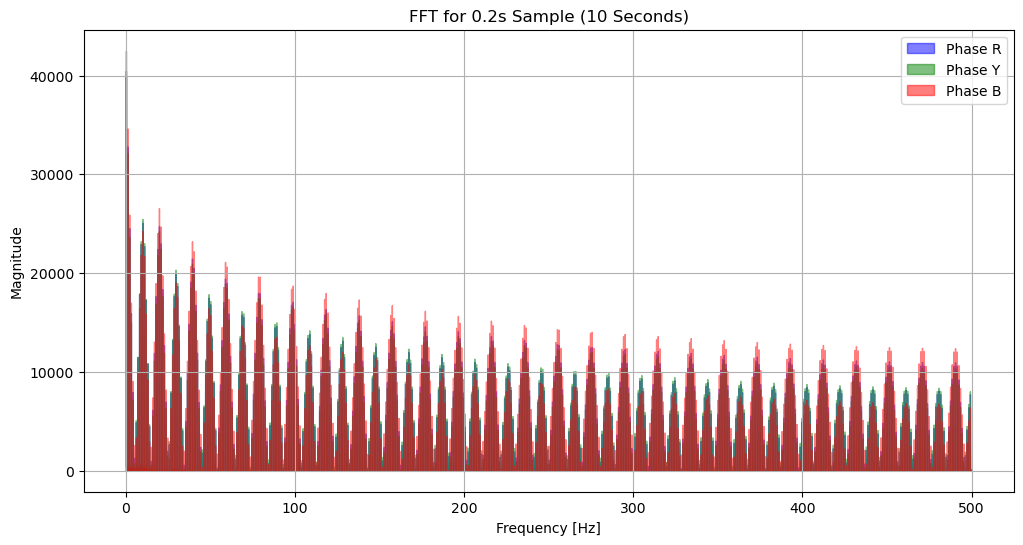

Plotting FFT for 0.5s...


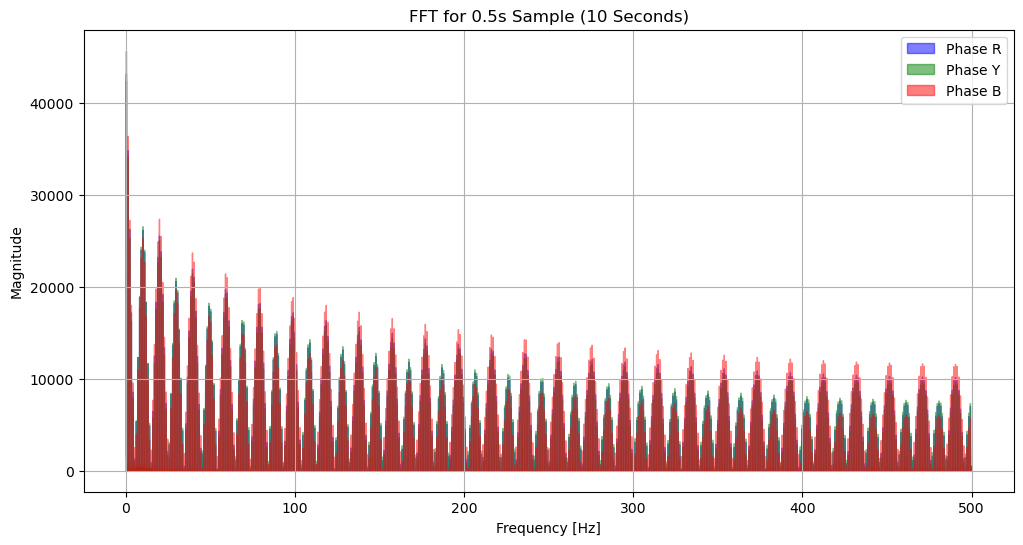

Plotting FFT for 1s...


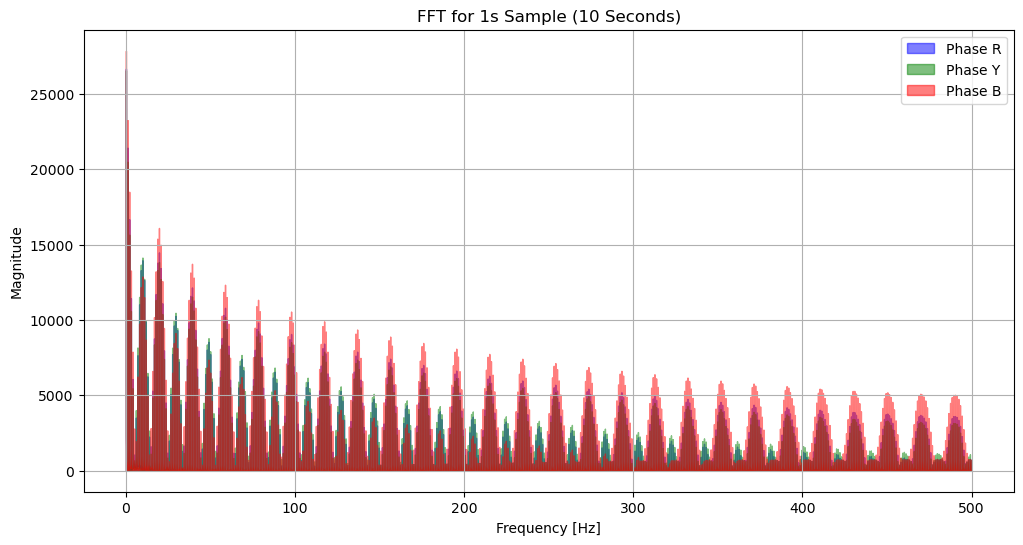

Plotting FFT for 2s...


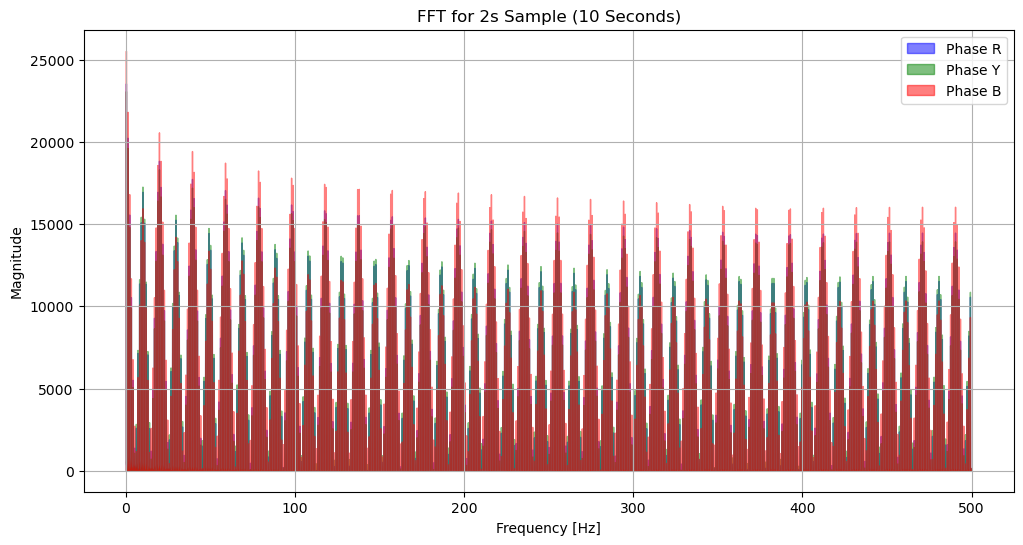

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft

def load_intermittent_fault_data(base_dir):
    """
    Load raw intermittent fault data from the specified directory.
    """
    intermittent_data = {}
    folders = ["0.2s", "0.5s", "1s", "2s"]

    for folder in folders:
        folder_path = os.path.join(base_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Folder {folder_path} does not exist. Skipping.")
            continue

        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)
                try:
                    # Load the CSV file
                    df = pd.read_csv(file_path, header=None)
                    current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

                    # Store the entire 10-second signal
                    if folder not in intermittent_data:
                        intermittent_data[folder] = []
                    intermittent_data[folder].append(current_data)

                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")

    return intermittent_data

def plot_fft(signal, folder_name):
    """
    Plot the FFT of the entire 10-second signal with blue background and green window.
    """
    fs = 1000  # Sampling frequency (1 kHz)
    n = len(signal)  # Number of samples
    freq = np.fft.fftfreq(n, d=1/fs)  # Frequency axis
    fft_result = np.abs(fft(signal, axis=0))  # Compute FFT for each phase

    # Plot FFT for Phase R
    plt.figure(figsize=(12, 6))
    plt.fill_between(freq[:n//2], 0, fft_result[:n//2, 0], color='blue', alpha=0.5, label="Phase R")
    plt.fill_between(freq[:n//2], 0, fft_result[:n//2, 1], color='green', alpha=0.5, label="Phase Y")
    plt.fill_between(freq[:n//2], 0, fft_result[:n//2, 2], color='red', alpha=0.5, label="Phase B")
    plt.title(f"FFT for {folder_name} Sample (10 Seconds)")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Magnitude")
    plt.legend()
    plt.grid()
    plt.show()

# Directory path to intermittent fault data
intermittent_fault_dir = "/home/ani/Downloads/Interturn_wvp/Y/"

# Load intermittent fault data
intermittent_data = load_intermittent_fault_data(intermittent_fault_dir)

# Check if data was loaded
if not intermittent_data:
    print("No intermittent fault data found! Check the directory structure and file paths.")
    exit()

# Plot FFT for one sample from each folder
for folder, data_list in intermittent_data.items():
    if data_list:  # Check if data exists for the folder
        print(f"Plotting FFT for {folder}...")
        sample = data_list[0]  # Take the first sample
        plot_fft(sample, folder)

Total files processed: 720
Total FFT segments for Fault: 4320
Total FFT segments for No Fault: 2880
Training FFT segments: 5760
Testing FFT segments: 647
Class 0 (Healthy) samples in training: 2304
Class 1 (Faulty) samples in training: 3456
Class 0 (Healthy) samples in testing: 576
Class 1 (Faulty) samples in testing: 71
Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7349 - loss: 0.4976 - val_accuracy: 0.5477 - val_loss: 0.8911
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9300 - loss: 0.1920 - val_accuracy: 0.7691 - val_loss: 0.4111
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9513 - loss: 0.1429 - val_accuracy: 0.9731 - val_loss: 0.1435
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9486 - loss: 0.1329 - val_accuracy: 0.9115 - val_loss: 0.2130
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9644 - loss: 0.0990 - val_accuracy: 0.9774 - val_loss: 0.0825
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━

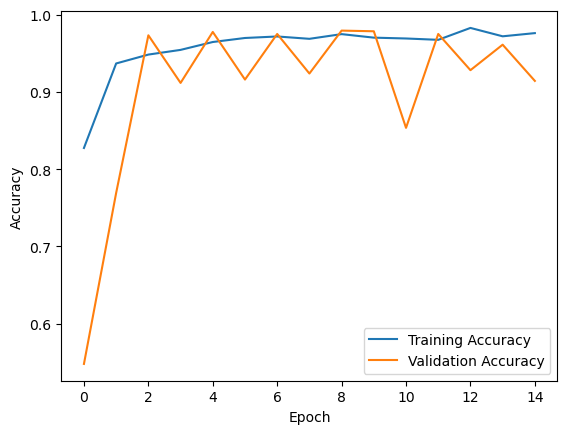

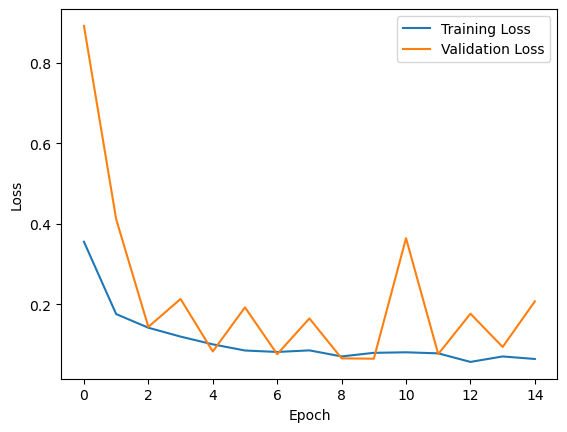

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 1000, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 1000, 128)      │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 1000, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 1000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 1000, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 1000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 1000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 64000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │     2,048,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,248,325 (23.84 MB)

 Trainable params: 2,082,625 (7.94 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 4,165,252 (15.89 MB)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       576
           1       0.95      1.00      0.97        71

    accuracy                           0.99       647
   macro avg       0.97      1.00      0.98       647
weighted avg       0.99      0.99      0.99       647



In [11]:
#TESTING INTERMITTENT FAULT WAVELET SYM4
import os
import numpy as np
import pandas as pd
from scipy.fft import fft
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, Dense, Flatten, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

def process_file(file_path, data_segments, labels, label, segment_length=1000):
    """
    Process a single file: split into segments, apply FFT, and assign labels.
    """
    try:
        # Load the CSV file
        df = pd.read_csv(file_path, header=None)
        current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

        # Split into 1-second segments (1000 samples per segment)
        segments = [current_data[i:i + segment_length] for i in range(0, len(current_data), segment_length) if i + segment_length <= len(current_data)]

        # Perform FFT on each segment and keep the shape as (segment_length, 3)
        for segment in segments:
            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT to each phase (R, Y, B)
            data_segments.append(fft_result)  # Shape: (segment_length, 3)
            labels.append(label)

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
    
    return data_segments, labels

def load_intermittent_fault_data(base_dir, segment_length=1000):
    """
    Load intermittent fault data from the specified directory and extract windows.
    """
    intermittent_data = []
    intermittent_labels = []

    # Define window extraction logic for each folder
    window_rules = {
        "0.2s": [(1000, 2000)],  # 1s to 2s
        "0.5s": [(1000, 2000)],  # 1s to 2s
        "1s": [(600, 1600), (1600, 2600)],  # 0.6s to 1.6s and 1.6s to 2.6s
        "2s": [(600, 1600), (2400, 3400)],  # 0.6s to 1.6s and 2.4s to 3.4s
    }

    for folder, windows in window_rules.items():
        folder_path = os.path.join(base_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Folder {folder_path} does not exist. Skipping.")
            continue

        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)
                try:
                    # Load the CSV file
                    df = pd.read_csv(file_path, header=None)
                    current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

                    # Extract the specified windows
                    for start, end in windows:
                        segment = current_data[start:end]
                        if len(segment) == segment_length:
                            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT
                            intermittent_data.append(fft_result)
                            intermittent_labels.append(1)  # Label for fault

                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")

    return np.array(intermittent_data), np.array(intermittent_labels)

def load_and_preprocess_data(data_dir, segment_length=1000, test_size=0.2, random_state=42):
    """
    Load and preprocess data from the directory, splitting fault and no-fault data separately.
    """
    fault_data = []
    no_fault_data = []
    fault_labels = []
    no_fault_labels = []
    file_count = 0  # Initialize file counter

    # Iterate over load levels (e.g., 0.5_A, 1_A, etc.)
    for load in os.listdir(data_dir):
        load_path = os.path.join(data_dir, load)
        if not os.path.isdir(load_path):
            continue

        # Check for Fault and No_Fault directories
        for condition in ["Fault", "No_Fault"]:
            condition_path = os.path.join(load_path, condition)
            if condition == "Fault":  # Handle fault conditions
                for phase in ["P2"]:  # Only process P1 for this NN
                    phase_path = os.path.join(condition_path, phase)
                    if os.path.exists(phase_path):
                        for file in os.listdir(phase_path):
                            if file.endswith(".csv"):
                                file_count += 1  # Increment the file counter
                                file_path = os.path.join(phase_path, file)
                                fault_data, fault_labels = process_file(file_path, fault_data, fault_labels, label=1, segment_length=segment_length)
            elif condition == "No_Fault":  # Handle no fault conditions
                if os.path.exists(condition_path):
                    for file in os.listdir(condition_path):
                        if file.endswith(".csv"):
                            file_count += 1  # Increment the file counter
                            file_path = os.path.join(condition_path, file)
                            no_fault_data, no_fault_labels = process_file(file_path, no_fault_data, no_fault_labels, label=0, segment_length=segment_length)

    print(f"Total files processed: {file_count}")  # Print the total file count
    print(f"Total FFT segments for Fault: {len(fault_data)}")
    print(f"Total FFT segments for No Fault: {len(no_fault_data)}")

    # Convert to numpy arrays
    fault_data = np.array(fault_data)
    no_fault_data = np.array(no_fault_data)
    fault_labels = np.array(fault_labels)
    no_fault_labels = np.array(no_fault_labels)

    # Split fault data into train and test sets
    X_fault_train, _, y_fault_train, _ = train_test_split(
        fault_data, fault_labels, test_size=test_size, random_state=random_state
    )

    # Split no-fault data into train and test sets
    X_no_fault_train, X_no_fault_test, y_no_fault_train, y_no_fault_test = train_test_split(
        no_fault_data, no_fault_labels, test_size=test_size, random_state=random_state
    )

    # Load intermittent fault data for testing
    intermittent_fault_dir = "/home/ani/Project/Interfault_sym4/Y/"
    X_intermittent_fault, y_intermittent_fault = load_intermittent_fault_data(intermittent_fault_dir, segment_length=segment_length)

    # Combine fault and no-fault data for training
    X_train = np.concatenate((X_fault_train, X_no_fault_train), axis=0)
    y_train = np.concatenate((y_fault_train, y_no_fault_train), axis=0)

    # Use intermittent fault data and no-fault test data for testing
    X_test = np.concatenate((X_intermittent_fault, X_no_fault_test), axis=0)
    y_test = np.concatenate((y_intermittent_fault, y_no_fault_test), axis=0)

    # Shuffle the training and testing data
    train_indices = np.arange(len(X_train))
    test_indices = np.arange(len(X_test))
    np.random.shuffle(train_indices)
    np.random.shuffle(test_indices)

    X_train = X_train[train_indices]
    y_train = y_train[train_indices]
    X_test = X_test[test_indices]
    y_test = y_test[test_indices]

    return X_train, X_test, y_train, y_test

# Directory path to data
base_dir = "/home/ani/DataNN/5kVA/Load"

# Load and preprocess data with 1-second intervals (1000 samples per segment)
segment_length = 1000  # Change to 500 if you want 500 samples per segment
X_train, X_test, y_train, y_test = load_and_preprocess_data(base_dir, segment_length=segment_length)

# Check if data was loaded
if X_train.size == 0 or X_test.size == 0:
    print("No data found! Check the directory structure and file paths.")
    exit()

# Print training and testing FFT segment counts
print(f"Training FFT segments: {len(X_train)}")
print(f"Testing FFT segments: {len(X_test)}")

# Check class distribution
print(f"Class 0 (Healthy) samples in training: {np.sum(y_train == 0)}")
print(f"Class 1 (Faulty) samples in training: {np.sum(y_train == 1)}")
print(f"Class 0 (Healthy) samples in testing: {np.sum(y_test == 0)}")
print(f"Class 1 (Faulty) samples in testing: {np.sum(y_test == 1)}")

# Define the CNN model with a bottleneck layer
def build_cnn_model(input_shape):
    inputs = Input(shape=input_shape)

    # Convolutional layers
    x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Conv1D(64, kernel_size=4, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Flatten()(x)

    # Bottleneck layer
    x = Dense(32)(x)  # Bottleneck size = 32
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting
    x = Activation('relu')(x)

    # Output layer
    outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Build the model
input_shape = (segment_length, 3)  # Input shape: (segment_length, 3)
cnn_model = build_cnn_model(input_shape)

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Add early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Add class weighting to address imbalance
class_weights = {0: 1.2, 1: 0.8}  # Adjust weights based on class imbalance

# Train the model with early stopping and class weighting
history = cnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    class_weight=class_weights
)

# Evaluate the model
loss, accuracy = cnn_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
cnn_model.summary()
# Additional evaluation
y_pred = (cnn_model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Total files processed: 720
Total FFT segments for Fault: 4320
Total FFT segments for No Fault: 2880
Training FFT segments: 5760
Testing FFT segments: 647
Class 0 (Healthy) samples in training: 2304
Class 1 (Faulty) samples in training: 3456
Class 0 (Healthy) samples in testing: 576
Class 1 (Faulty) samples in testing: 71
Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7252 - loss: 0.4959 - val_accuracy: 0.7352 - val_loss: 0.4703
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9297 - loss: 0.1921 - val_accuracy: 0.9045 - val_loss: 0.2383
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9481 - loss: 0.1427 - val_accuracy: 0.9774 - val_loss: 0.0945
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9644 - loss: 0.1102 - val_accuracy: 0.9714 - val_loss: 0.1028
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9662 - loss: 0.0895 - val_accuracy: 0.9757 - val_loss: 0.0976
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━

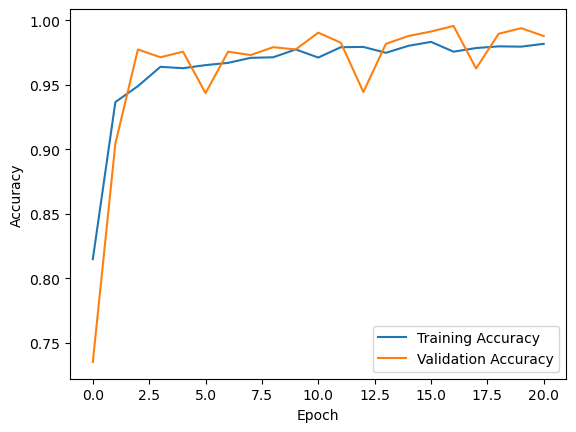

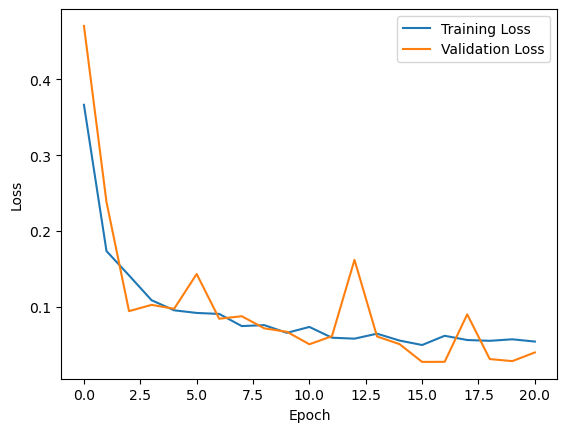

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 1000, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 1000, 128)      │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 1000, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 1000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 1000, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 1000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 1000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 64000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │     2,048,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,248,325 (23.84 MB)

 Trainable params: 2,082,625 (7.94 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 4,165,252 (15.89 MB)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       576
           1       0.99      1.00      0.99        71

    accuracy                           1.00       647
   macro avg       0.99      1.00      1.00       647
weighted avg       1.00      1.00      1.00       647



In [12]:
#TESTING INTERMITTENT FAULT WAVELET bior2.2
import os
import numpy as np
import pandas as pd
from scipy.fft import fft
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, Dense, Flatten, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

def process_file(file_path, data_segments, labels, label, segment_length=1000):
    """
    Process a single file: split into segments, apply FFT, and assign labels.
    """
    try:
        # Load the CSV file
        df = pd.read_csv(file_path, header=None)
        current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

        # Split into 1-second segments (1000 samples per segment)
        segments = [current_data[i:i + segment_length] for i in range(0, len(current_data), segment_length) if i + segment_length <= len(current_data)]

        # Perform FFT on each segment and keep the shape as (segment_length, 3)
        for segment in segments:
            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT to each phase (R, Y, B)
            data_segments.append(fft_result)  # Shape: (segment_length, 3)
            labels.append(label)

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
    
    return data_segments, labels

def load_intermittent_fault_data(base_dir, segment_length=1000):
    """
    Load intermittent fault data from the specified directory and extract windows.
    """
    intermittent_data = []
    intermittent_labels = []

    # Define window extraction logic for each folder
    window_rules = {
        "0.2s": [(1000, 2000)],  # 1s to 2s
        "0.5s": [(1000, 2000)],  # 1s to 2s
        "1s": [(600, 1600), (1600, 2600)],  # 0.6s to 1.6s and 1.6s to 2.6s
        "2s": [(600, 1600), (2400, 3400)],  # 0.6s to 1.6s and 2.4s to 3.4s
    }

    for folder, windows in window_rules.items():
        folder_path = os.path.join(base_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Folder {folder_path} does not exist. Skipping.")
            continue

        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)
                try:
                    # Load the CSV file
                    df = pd.read_csv(file_path, header=None)
                    current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

                    # Extract the specified windows
                    for start, end in windows:
                        segment = current_data[start:end]
                        if len(segment) == segment_length:
                            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT
                            intermittent_data.append(fft_result)
                            intermittent_labels.append(1)  # Label for fault

                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")

    return np.array(intermittent_data), np.array(intermittent_labels)

def load_and_preprocess_data(data_dir, segment_length=1000, test_size=0.2, random_state=42):
    """
    Load and preprocess data from the directory, splitting fault and no-fault data separately.
    """
    fault_data = []
    no_fault_data = []
    fault_labels = []
    no_fault_labels = []
    file_count = 0  # Initialize file counter

    # Iterate over load levels (e.g., 0.5_A, 1_A, etc.)
    for load in os.listdir(data_dir):
        load_path = os.path.join(data_dir, load)
        if not os.path.isdir(load_path):
            continue

        # Check for Fault and No_Fault directories
        for condition in ["Fault", "No_Fault"]:
            condition_path = os.path.join(load_path, condition)
            if condition == "Fault":  # Handle fault conditions
                for phase in ["P2"]:  # Only process P1 for this NN
                    phase_path = os.path.join(condition_path, phase)
                    if os.path.exists(phase_path):
                        for file in os.listdir(phase_path):
                            if file.endswith(".csv"):
                                file_count += 1  # Increment the file counter
                                file_path = os.path.join(phase_path, file)
                                fault_data, fault_labels = process_file(file_path, fault_data, fault_labels, label=1, segment_length=segment_length)
            elif condition == "No_Fault":  # Handle no fault conditions
                if os.path.exists(condition_path):
                    for file in os.listdir(condition_path):
                        if file.endswith(".csv"):
                            file_count += 1  # Increment the file counter
                            file_path = os.path.join(condition_path, file)
                            no_fault_data, no_fault_labels = process_file(file_path, no_fault_data, no_fault_labels, label=0, segment_length=segment_length)

    print(f"Total files processed: {file_count}")  # Print the total file count
    print(f"Total FFT segments for Fault: {len(fault_data)}")
    print(f"Total FFT segments for No Fault: {len(no_fault_data)}")

    # Convert to numpy arrays
    fault_data = np.array(fault_data)
    no_fault_data = np.array(no_fault_data)
    fault_labels = np.array(fault_labels)
    no_fault_labels = np.array(no_fault_labels)

    # Split fault data into train and test sets
    X_fault_train, _, y_fault_train, _ = train_test_split(
        fault_data, fault_labels, test_size=test_size, random_state=random_state
    )

    # Split no-fault data into train and test sets
    X_no_fault_train, X_no_fault_test, y_no_fault_train, y_no_fault_test = train_test_split(
        no_fault_data, no_fault_labels, test_size=test_size, random_state=random_state
    )

    # Load intermittent fault data for testing
    intermittent_fault_dir = "/home/ani/Project/Interfault_bior2.2/Y/"
    X_intermittent_fault, y_intermittent_fault = load_intermittent_fault_data(intermittent_fault_dir, segment_length=segment_length)

    # Combine fault and no-fault data for training
    X_train = np.concatenate((X_fault_train, X_no_fault_train), axis=0)
    y_train = np.concatenate((y_fault_train, y_no_fault_train), axis=0)

    # Use intermittent fault data and no-fault test data for testing
    X_test = np.concatenate((X_intermittent_fault, X_no_fault_test), axis=0)
    y_test = np.concatenate((y_intermittent_fault, y_no_fault_test), axis=0)

    # Shuffle the training and testing data
    train_indices = np.arange(len(X_train))
    test_indices = np.arange(len(X_test))
    np.random.shuffle(train_indices)
    np.random.shuffle(test_indices)

    X_train = X_train[train_indices]
    y_train = y_train[train_indices]
    X_test = X_test[test_indices]
    y_test = y_test[test_indices]

    return X_train, X_test, y_train, y_test

# Directory path to data
base_dir = "/home/ani/DataNN/5kVA/Load"

# Load and preprocess data with 1-second intervals (1000 samples per segment)
segment_length = 1000  # Change to 500 if you want 500 samples per segment
X_train, X_test, y_train, y_test = load_and_preprocess_data(base_dir, segment_length=segment_length)

# Check if data was loaded
if X_train.size == 0 or X_test.size == 0:
    print("No data found! Check the directory structure and file paths.")
    exit()

# Print training and testing FFT segment counts
print(f"Training FFT segments: {len(X_train)}")
print(f"Testing FFT segments: {len(X_test)}")

# Check class distribution
print(f"Class 0 (Healthy) samples in training: {np.sum(y_train == 0)}")
print(f"Class 1 (Faulty) samples in training: {np.sum(y_train == 1)}")
print(f"Class 0 (Healthy) samples in testing: {np.sum(y_test == 0)}")
print(f"Class 1 (Faulty) samples in testing: {np.sum(y_test == 1)}")

# Define the CNN model with a bottleneck layer
def build_cnn_model(input_shape):
    inputs = Input(shape=input_shape)

    # Convolutional layers
    x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Conv1D(64, kernel_size=4, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Flatten()(x)

    # Bottleneck layer
    x = Dense(32)(x)  # Bottleneck size = 32
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting
    x = Activation('relu')(x)

    # Output layer
    outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Build the model
input_shape = (segment_length, 3)  # Input shape: (segment_length, 3)
cnn_model = build_cnn_model(input_shape)

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Add early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Add class weighting to address imbalance
class_weights = {0: 1.2, 1: 0.8}  # Adjust weights based on class imbalance

# Train the model with early stopping and class weighting
history = cnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    class_weight=class_weights
)

# Evaluate the model
loss, accuracy = cnn_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
cnn_model.summary()
# Additional evaluation
y_pred = (cnn_model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Total files processed: 720
Total FFT segments for Fault: 4320
Total FFT segments for No Fault: 2880
Training FFT segments: 5760
Testing FFT segments: 647
Class 0 (Healthy) samples in training: 2304
Class 1 (Faulty) samples in training: 3456
Class 0 (Healthy) samples in testing: 576
Class 1 (Faulty) samples in testing: 71
Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7822 - loss: 0.4509 - val_accuracy: 0.7153 - val_loss: 0.4869
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9297 - loss: 0.1894 - val_accuracy: 0.9488 - val_loss: 0.1530
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9434 - loss: 0.1505 - val_accuracy: 0.9766 - val_loss: 0.0973
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9539 - loss: 0.1245 - val_accuracy: 0.9896 - val_loss: 0.0618
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9518 - loss: 0.1187 - val_accuracy: 0.9592 - val_loss: 0.1305
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━

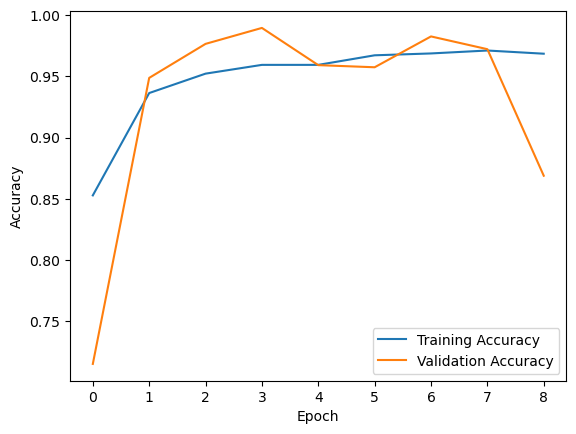

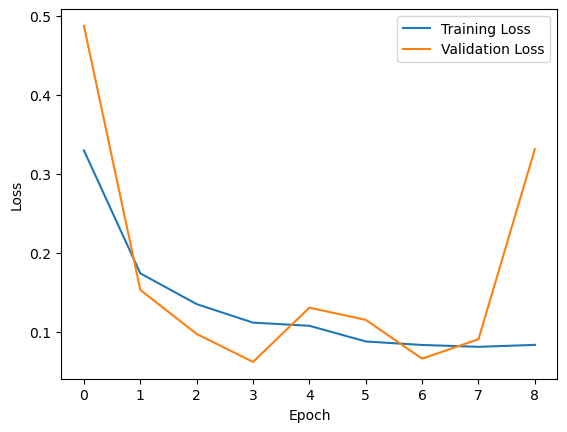

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 1000, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 1000, 128)      │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 1000, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 1000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 1000, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 1000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 1000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 64000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │     2,048,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,248,325 (23.84 MB)

 Trainable params: 2,082,625 (7.94 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 4,165,252 (15.89 MB)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       576
           1       0.95      1.00      0.97        71

    accuracy                           0.99       647
   macro avg       0.97      1.00      0.98       647
weighted avg       0.99      0.99      0.99       647



In [13]:
#TESTING INTERMITTENT FAULT WAVELET coif1
import os
import numpy as np
import pandas as pd
from scipy.fft import fft
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, Dense, Flatten, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

def process_file(file_path, data_segments, labels, label, segment_length=1000):
    """
    Process a single file: split into segments, apply FFT, and assign labels.
    """
    try:
        # Load the CSV file
        df = pd.read_csv(file_path, header=None)
        current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

        # Split into 1-second segments (1000 samples per segment)
        segments = [current_data[i:i + segment_length] for i in range(0, len(current_data), segment_length) if i + segment_length <= len(current_data)]

        # Perform FFT on each segment and keep the shape as (segment_length, 3)
        for segment in segments:
            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT to each phase (R, Y, B)
            data_segments.append(fft_result)  # Shape: (segment_length, 3)
            labels.append(label)

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
    
    return data_segments, labels

def load_intermittent_fault_data(base_dir, segment_length=1000):
    """
    Load intermittent fault data from the specified directory and extract windows.
    """
    intermittent_data = []
    intermittent_labels = []

    # Define window extraction logic for each folder
    window_rules = {
        "0.2s": [(1000, 2000)],  # 1s to 2s
        "0.5s": [(1000, 2000)],  # 1s to 2s
        "1s": [(600, 1600), (1600, 2600)],  # 0.6s to 1.6s and 1.6s to 2.6s
        "2s": [(600, 1600), (2400, 3400)],  # 0.6s to 1.6s and 2.4s to 3.4s
    }

    for folder, windows in window_rules.items():
        folder_path = os.path.join(base_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Folder {folder_path} does not exist. Skipping.")
            continue

        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)
                try:
                    # Load the CSV file
                    df = pd.read_csv(file_path, header=None)
                    current_data = df.iloc[:, -3:].values  # Take the last 3 columns (R, Y, B currents)

                    # Extract the specified windows
                    for start, end in windows:
                        segment = current_data[start:end]
                        if len(segment) == segment_length:
                            fft_result = np.abs(fft(segment, axis=0))  # Apply FFT
                            intermittent_data.append(fft_result)
                            intermittent_labels.append(1)  # Label for fault

                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")

    return np.array(intermittent_data), np.array(intermittent_labels)

def load_and_preprocess_data(data_dir, segment_length=1000, test_size=0.2, random_state=42):
    """
    Load and preprocess data from the directory, splitting fault and no-fault data separately.
    """
    fault_data = []
    no_fault_data = []
    fault_labels = []
    no_fault_labels = []
    file_count = 0  # Initialize file counter

    # Iterate over load levels (e.g., 0.5_A, 1_A, etc.)
    for load in os.listdir(data_dir):
        load_path = os.path.join(data_dir, load)
        if not os.path.isdir(load_path):
            continue

        # Check for Fault and No_Fault directories
        for condition in ["Fault", "No_Fault"]:
            condition_path = os.path.join(load_path, condition)
            if condition == "Fault":  # Handle fault conditions
                for phase in ["P2"]:  # Only process P1 for this NN
                    phase_path = os.path.join(condition_path, phase)
                    if os.path.exists(phase_path):
                        for file in os.listdir(phase_path):
                            if file.endswith(".csv"):
                                file_count += 1  # Increment the file counter
                                file_path = os.path.join(phase_path, file)
                                fault_data, fault_labels = process_file(file_path, fault_data, fault_labels, label=1, segment_length=segment_length)
            elif condition == "No_Fault":  # Handle no fault conditions
                if os.path.exists(condition_path):
                    for file in os.listdir(condition_path):
                        if file.endswith(".csv"):
                            file_count += 1  # Increment the file counter
                            file_path = os.path.join(condition_path, file)
                            no_fault_data, no_fault_labels = process_file(file_path, no_fault_data, no_fault_labels, label=0, segment_length=segment_length)

    print(f"Total files processed: {file_count}")  # Print the total file count
    print(f"Total FFT segments for Fault: {len(fault_data)}")
    print(f"Total FFT segments for No Fault: {len(no_fault_data)}")

    # Convert to numpy arrays
    fault_data = np.array(fault_data)
    no_fault_data = np.array(no_fault_data)
    fault_labels = np.array(fault_labels)
    no_fault_labels = np.array(no_fault_labels)

    # Split fault data into train and test sets
    X_fault_train, _, y_fault_train, _ = train_test_split(
        fault_data, fault_labels, test_size=test_size, random_state=random_state
    )

    # Split no-fault data into train and test sets
    X_no_fault_train, X_no_fault_test, y_no_fault_train, y_no_fault_test = train_test_split(
        no_fault_data, no_fault_labels, test_size=test_size, random_state=random_state
    )

    # Load intermittent fault data for testing
    intermittent_fault_dir = "/home/ani/Project/Interfault_coif1/Y/"
    X_intermittent_fault, y_intermittent_fault = load_intermittent_fault_data(intermittent_fault_dir, segment_length=segment_length)

    # Combine fault and no-fault data for training
    X_train = np.concatenate((X_fault_train, X_no_fault_train), axis=0)
    y_train = np.concatenate((y_fault_train, y_no_fault_train), axis=0)

    # Use intermittent fault data and no-fault test data for testing
    X_test = np.concatenate((X_intermittent_fault, X_no_fault_test), axis=0)
    y_test = np.concatenate((y_intermittent_fault, y_no_fault_test), axis=0)

    # Shuffle the training and testing data
    train_indices = np.arange(len(X_train))
    test_indices = np.arange(len(X_test))
    np.random.shuffle(train_indices)
    np.random.shuffle(test_indices)

    X_train = X_train[train_indices]
    y_train = y_train[train_indices]
    X_test = X_test[test_indices]
    y_test = y_test[test_indices]

    return X_train, X_test, y_train, y_test

# Directory path to data
base_dir = "/home/ani/DataNN/5kVA/Load"

# Load and preprocess data with 1-second intervals (1000 samples per segment)
segment_length = 1000  # Change to 500 if you want 500 samples per segment
X_train, X_test, y_train, y_test = load_and_preprocess_data(base_dir, segment_length=segment_length)

# Check if data was loaded
if X_train.size == 0 or X_test.size == 0:
    print("No data found! Check the directory structure and file paths.")
    exit()

# Print training and testing FFT segment counts
print(f"Training FFT segments: {len(X_train)}")
print(f"Testing FFT segments: {len(X_test)}")

# Check class distribution
print(f"Class 0 (Healthy) samples in training: {np.sum(y_train == 0)}")
print(f"Class 1 (Faulty) samples in training: {np.sum(y_train == 1)}")
print(f"Class 0 (Healthy) samples in testing: {np.sum(y_test == 0)}")
print(f"Class 1 (Faulty) samples in testing: {np.sum(y_test == 1)}")

# Define the CNN model with a bottleneck layer
def build_cnn_model(input_shape):
    inputs = Input(shape=input_shape)

    # Convolutional layers
    x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Conv1D(64, kernel_size=4, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting

    x = Flatten()(x)

    # Bottleneck layer
    x = Dense(32)(x)  # Bottleneck size = 32
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout to reduce overfitting
    x = Activation('relu')(x)

    # Output layer
    outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Build the model
input_shape = (segment_length, 3)  # Input shape: (segment_length, 3)
cnn_model = build_cnn_model(input_shape)

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Add early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Add class weighting to address imbalance
class_weights = {0: 1.2, 1: 0.8}  # Adjust weights based on class imbalance

# Train the model with early stopping and class weighting
history = cnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    class_weight=class_weights
)

# Evaluate the model
loss, accuracy = cnn_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
cnn_model.summary()
# Additional evaluation
y_pred = (cnn_model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))